In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!git clone https://github.com/razorx89/roco-dataset.git

Cloning into 'roco-dataset'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 114 (delta 7), reused 20 (delta 7), pack-reused 91 (from 1)
Receiving objects: 100% (114/114), 13.01 MiB | 14.48 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [ ]:
!python3 /content/roco-dataset/scripts/fetch.py


Streaming output truncated to the last 5000 lines.
89.311% | 41617/46598 | PMC4432449
89.313% | 41618/46598 | PMC1978243
89.315% | 41619/46598 | PMC3953627
89.317% | 41620/46598 | PMC4675004
89.319% | 41621/46598 | PMC5502573
89.321% | 41622/46598 | PMC4460548
89.324% | 41623/46598 | PMC3290114
89.326% | 41624/46598 | PMC4435852
89.328% | 41625/46598 | PMC2740835
89.330% | 41626/46598 | PMC2253542
89.332% | 41627/46598 | PMC4055357
89.334% | 41628/46598 | PMC4564506
89.336% | 41629/46598 | PMC3954297
89.339% | 41630/46598 | PMC1368977
89.341% | 41631/46598 | PMC3015802
89.343% | 41632/46598 | PMC4143510
89.345% | 41633/46598 | PMC3627160
89.347% | 41634/46598 | PMC2841377
89.349% | 41635/46598 | PMC2629172
89.351% | 41636/46598 | PMC4152832
89.354% | 41637/46598 | PMC3340973
89.356% | 41638/46598 | PMC5133587
89.358% | 41639/46598 | PMC4379335
89.360% | 41640/46598 | PMC4224691
89.362% | 41641/46598 | PMC5721486
89.364% | 41642/46598 | PMC4897456
89.366% | 41643/46598 | PMC5739534
89.3

In [ ]:
import shutil

# Specify the source path in Colab and the destination in Google Drive
source_path = '/content/roco-dataset'
destination_path = '/content/drive/MyDrive/ROCO/'

# Move the file or folder
shutil.move(source_path, destination_path)


'/content/drive/MyDrive/ROCO/'

In [ ]:

!zip -r roco.zip . - i /content/drive/MyDrive/ROCO_dataset/

	zip warning: name not matched: i
	zip warning: name not matched: /content/drive/MyDrive/ROCO_dataset/
  adding: .config/ (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2024.11.08/ (stored 0%)
  adding: .config/logs/2024.11.08/14.18.56.060217.log (deflated 93%)
  adding: .config/logs/2024.11.08/14.19.29.280723.log (deflated 86%)
  adding: .config/logs/2024.11.08/14.19.42.809213.log (deflated 56%)
  adding: .config/logs/2024.11.08/14.19.42.125850.log (deflated 57%)
  adding: .config/logs/2024.11.08/14.19.30.265814.log (deflated 58%)
  adding: .config/logs/2024.11.08/14.19.17.448702.log (deflated 58%)
  adding: .config/active_config (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/gce (stored 0%)
  adding: .config/hidden_gcloud_config_universe_descriptor_data_cache_confi

In [2]:

import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms as transforms





In [3]:
df = pd.read_table('/content/drive/MyDrive/ROCO/data/train/radiology/captions.txt',header=None,names = ['image_id','caption'])
df

,image_id,caption
0,ROCO_00002,Computed tomography scan in axial view showin...
1,ROCO_00003,Bacterial contamination occurred after comple...
2,ROCO_00004,The patient had residual paralysis of the han...
3,ROCO_00005,Panoramic radiograph after immediate loading.
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at t...
...,...,...
65445,ROCO_81819,Initial CT abdomen with contrast showing a di...
65446,ROCO_81820,44-year-old male patient after surgical amput...
65447,ROCO_81821,Primary pulmonary tuberculosis in 18-year-old...
65448,ROCO_81822,"MRI brain with gadolinium, coronal view, show..."


In [4]:
df['caption'].describe()

,caption
count,65450
unique,64772
top,Initial panoramic radiograph.
freq,19


In [5]:
df['caption'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 65450 entries, 0 to 65449
Series name: caption
Non-Null Count  Dtype 
--------------  ----- 
65450 non-null  object
dtypes: object(1)
memory usage: 511.5+ KB


In [6]:
df['caption'].tail(10)

,caption
65440,Coronal CT image demonstrates the duodenum co...
65441,Spino-iliac angle (SIA): lines were drawn alo...
65442,Hinchey stage III. Intravenous and rectal con...
65443,Decompression tube is inserted followed by th...
65444,Doppler ultrasound revealed extensive thrombo...
65445,Initial CT abdomen with contrast showing a di...
65446,44-year-old male patient after surgical amput...
65447,Primary pulmonary tuberculosis in 18-year-old...
65448,"MRI brain with gadolinium, coronal view, show..."
65449,Contrast-enhanced 3D MRL image of the lower e...


In [7]:
df.columns

Index(['image_id', 'caption'], dtype='object')

In [8]:
print(df.isnull)
#print(df.notnull)

<bound method DataFrame.isnull of          image_id                                            caption
0      ROCO_00002   Computed tomography scan in axial view showin...
1      ROCO_00003   Bacterial contamination occurred after comple...
2      ROCO_00004   The patient had residual paralysis of the han...
3      ROCO_00005      Panoramic radiograph after immediate loading.
4      ROCO_00007   Plain abdomen x-ray: Multiple air levels at t...
...           ...                                                ...
65445  ROCO_81819   Initial CT abdomen with contrast showing a di...
65446  ROCO_81820   44-year-old male patient after surgical amput...
65447  ROCO_81821   Primary pulmonary tuberculosis in 18-year-old...
65448  ROCO_81822   MRI brain with gadolinium, coronal view, show...
65449  ROCO_81823   Contrast-enhanced 3D MRL image of the lower e...

[65450 rows x 2 columns]>


In [9]:
df['caption'].value_counts()

,count
caption,
Initial panoramic radiograph.,19
Preoperative radiograph,15
Postoperative radiograph,13
Chest X-ray,11
Final panoramic radiograph.,11
...,...
Computed tomography scan at the level of the lateral ventricles. There is a thin layer of acute subdural hematoma identified on the left with a minimal midline shift (arrow). A = anterior; P = posterior; L = left; R = right.,1
Magnetic resonance imaging of the mass,1
"Computed tomography image of the abdominal aorta.In Roman numerals the infra renal distances are portrayed. I: 0 mm, II: 7.5 mm, and III: 15 mm. To provide a standardized method for measuring the distances as mentioned above, first the midline of the aortic neck is chosen. The perpendicular line is then placed at the point where the lowest renal artery branches from the aorta. In the caudal direction from this point (I) and parallel to the midline, a distance of 7.5 and of 15 mm is measured to identify point II and III, respectively.",1


In [10]:
print(df.drop_duplicates(inplace=True))

None


In [11]:
pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.1/511.1 kB 7.1 MB/s eta 0:00:00


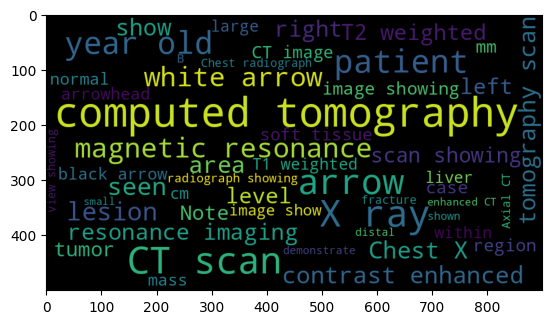

In [12]:
from wordcloud import WordCloud
caption_text=' '.join(df['caption'].astype(str))
wordcloud=WordCloud(width=900,height=500,max_words=50).generate(caption_text)
plt.imshow(wordcloud)

Loading dlink.txt from radiology

In [13]:

dlink_url='/content/drive/MyDrive/ROCO/data/test/non-radiology/dlinks.txt'
dlink = pd.read_table(dlink_url,header = None,names=['image_id','dlink','image'])
dlink

,image_id,dlink,image
0,ROCO_81827,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,1678-7757-jaos-14-02-0117-gf05.jpg
1,ROCO_81835,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,0036-4665-rimtsp-56-01-00092-gf01.jpg
2,ROCO_81851,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,opth-9-169Fig1.jpg
3,ROCO_81853,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,10561_2011_9244_Fig1_HTML.jpg
4,ROCO_81857,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,jsls-1-1-83-g02.jpg
...,...,...,...
607,ROCO_87910,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,10-7162-s-1809-97772012000400015-i160415-2.jpg
608,ROCO_87912,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,alm-35-657-g001.jpg
609,ROCO_87919,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,BMRI2015-475392.002.jpg
610,ROCO_87932,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,1471-2202-14-S1-P193-1.jpg


In [14]:
# Add a new column 'description_length' that stores the length of each description
dlink['description_length'] = dlink['dlink'].str.len()

# Display the first few rows to verify the new column
print(dlink.head())

     image_id                                              dlink  \
0  ROCO_81827  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
1  ROCO_81835  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
2  ROCO_81851  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
3  ROCO_81853  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
4  ROCO_81857  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   

                                   image  description_length  
0     1678-7757-jaos-14-02-0117-gf05.jpg                  93  
1  0036-4665-rimtsp-56-01-00092-gf01.jpg                  93  
2                     opth-9-169Fig1.jpg                  93  
3          10561_2011_9244_Fig1_HTML.jpg                  93  
4                    jsls-1-1-83-g02.jpg                  93  


In [15]:
dlink['description_length'].describe()

,description_length
count,612.000000
mean,92.988562
std,0.106422
min,92.000000
25%,93.000000
50%,93.000000
75%,93.000000
max,93.000000


In [16]:
import pandas as pd
import os

# Load captions data
textdata = pd.read_table('/content/drive/MyDrive/ROCO/data/train/radiology/captions.txt', header=None, names=['Image_ID', 'caption'])

# Create a DataFrame for image files
image_files = r"/content/drive/MyDrive/ROCO/data/train/radiology/images"
image_files_list = os.listdir(image_files)
image_files_df = pd.DataFrame(image_files_list, columns=['image_file'])

# Add an index column to both DataFrames to ensure correct alignment
textdata['index'] = textdata.index
image_files_df['index'] = image_files_df.index

# Merge based on the index column
merged_df = pd.merge(image_files_df, textdata, on='index', how='inner')

# Reorder columns to display image_file first
merged_df = merged_df[['image_file', 'caption']]

# Display the result (ensure both columns are properly aligned)
print(merged_df.head(10))  # Show the first 10 rows, adjust as necessary


       image_file                                            caption
0  ROCO_76568.jpg   Computed tomography scan in axial view showin...
1  ROCO_76578.jpg   Bacterial contamination occurred after comple...
2  ROCO_76580.jpg   The patient had residual paralysis of the han...
3  ROCO_76582.jpg      Panoramic radiograph after immediate loading.
4  ROCO_76595.jpg   Plain abdomen x-ray: Multiple air levels at t...
5  ROCO_76620.jpg   A 3-year-old child with visual difficulties. ...
6  ROCO_76629.jpg   Showing the subtrochanteric fracture in the p...
7  ROCO_76625.jpg   Post orthodontic treatment. Root canal therap...
8  ROCO_76638.jpg   Two sequential thrombi in the distal segment ...
9  ROCO_76630.jpg   An example of MRI image that takes advantage ...


list contains of images

In [21]:
img ="/content/drive/MyDrive/ROCO/data/train/radiology/images"
list1 = []
if os.path.exists(img):
    for file in os.listdir(img):
        list1.append(file)
else:
    print(f"The path {img} does not exist.")
len(list1)

48085



Display images with their respective captions

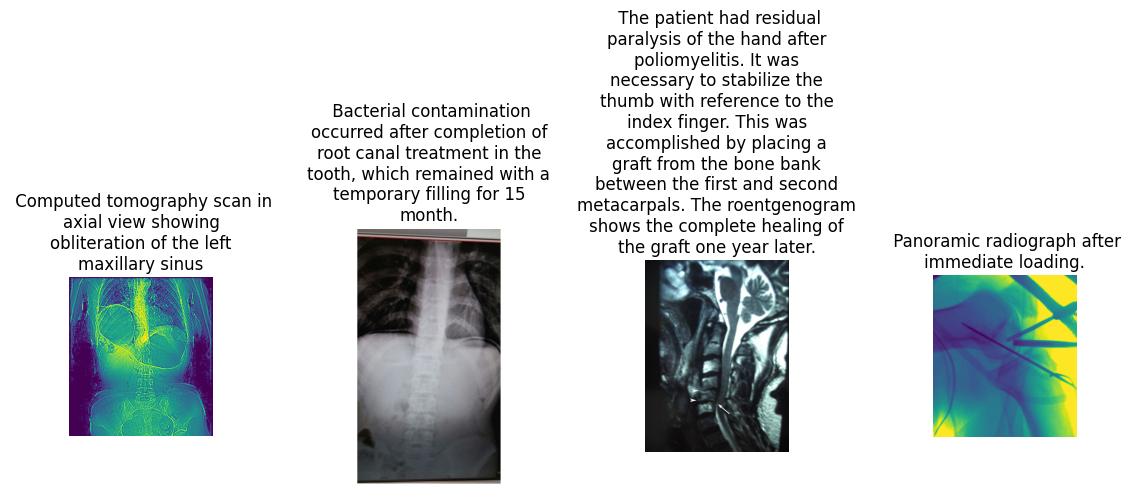

In [22]:
import textwrap

file_names1 = os.listdir(img)
wrap_width = 30

fig, axs = plt.subplots(1,4, figsize=(13, 15))

plt.subplots_adjust(wspace = 1,hspace=1)
axs = axs.flatten()
for i in range(4):
    file_path = os.path.join(img, list1[i])
    image = Image.open(file_path)
    caption = df["caption"][i]
    wrapped_caption = "\n".join(textwrap.wrap(caption, wrap_width))
    axs[i].imshow(image)
    axs[i].set_title(wrapped_caption)
    axs[i].axis('off')

plt.show()

In [23]:

data_dir = '/content/drive/MyDrive/ROCO/data'

# Initialize an empty list to store the data
data = []

# Iterate through each split (train, test, validation)
for split in ['train', 'test', 'validation']:
    split_dir = os.path.join(data_dir, split)

    # Iterate through each category (radiology, non-radiology)
    for category in ['radiology', 'non-radiology']:
        category_dir = os.path.join(split_dir, category)
        captions_file = os.path.join(category_dir, 'captions.txt')

        # Read captions.txt if it exists
        if os.path.exists(captions_file):
            with open(captions_file, 'r') as file:
                # Read each line in the file as a caption
                for line in (file):
                    caption = line[12:].strip()
                    id = line[:12]
                    label = 'radiology' if category == 'radiology' else 'non-radiology'
                    # Append the caption, label, and split type to the data list
                    data.append([id,caption, label, split])

# Create a DataFrame with the collected data
data = pd.DataFrame(data, columns=['image_id','Caption', 'Label', 'Split'])

data

,image_id,Caption,Label,Split
0,ROCO_00002\t,Computed tomography scan in axial view showing...,radiology,train
1,ROCO_00003\t,Bacterial contamination occurred after complet...,radiology,train
2,ROCO_00004\t,The patient had residual paralysis of the hand...,radiology,train
3,ROCO_00005\t,Panoramic radiograph after immediate loading.,radiology,train
4,ROCO_00007\t,Plain abdomen x-ray: Multiple air levels at th...,radiology,train
...,...,...,...,...
87922,ROCO_87894\t,Scanning electron photomicrograph of blood cel...,non-radiology,validation
87923,ROCO_87904\t,SEM of Solenopsis elhawagryi sp. n. minor work...,non-radiology,validation
87924,ROCO_87918\t,Under visualization through the anterolateral ...,non-radiology,validation
87925,ROCO_87936\t,The endoscopic view demonstrated progressive d...,non-radiology,validation


<ipython-input-24-04817d63bd60>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_counts.index, y=split_counts.values, palette=['green', 'yellow', 'blue'])


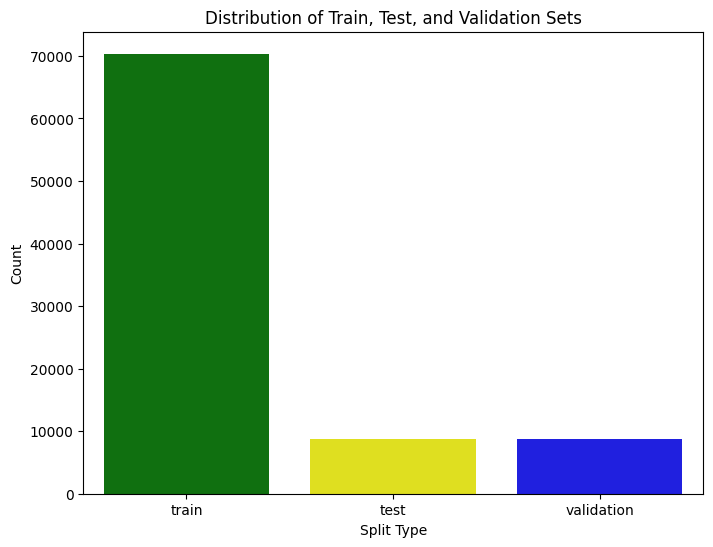

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'Split' contains categories like 'train', 'test', and 'validation'
split_counts = data['Split'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=split_counts.index, y=split_counts.values, palette=['green', 'yellow', 'blue'])
plt.title('Distribution of Train, Test, and Validation Sets')
plt.xlabel('Split Type')
plt.ylabel('Count')
plt.show()


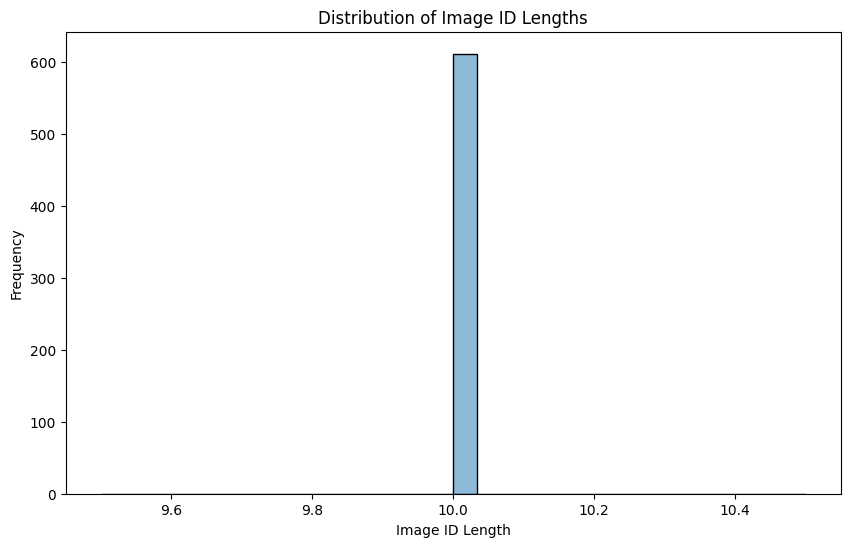

In [25]:
dlink['image_id_length'] = dlink['image_id'].astype(str).apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(dlink['image_id_length'], bins=30, kde=True)
plt.title('Distribution of Image ID Lengths')
plt.xlabel('Image ID Length')
plt.ylabel('Frequency')
plt.show()


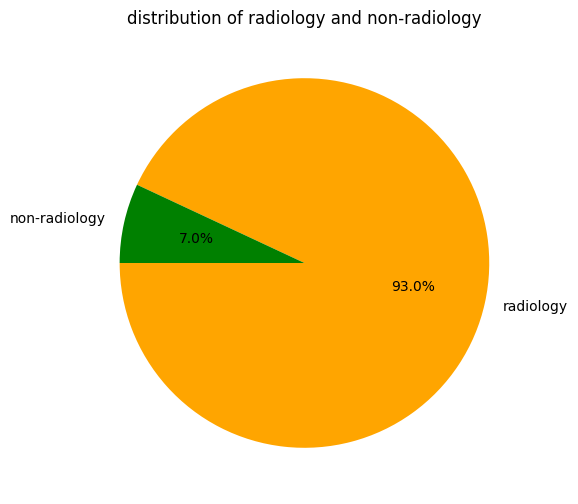

In [26]:
label_counts = data['Label'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',startangle=180,colors=['orange','green'])
plt.title('distribution of radiology and non-radiology')
plt.show()

IMage Preprocessing

In [27]:
import cv2
img_dir = "/content/drive/MyDrive/ROCO/data/train/radiology/images"

image_files=[f for f in os.listdir(img_dir) if f.endswith(".jpg")]

img_path=os.path.join(img_dir,image_files[50])



array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[254, 254, 254],
        [255, 255, 255],
        [133, 133, 133],
        ...,
        [  6,   4,   4],
        [128, 128, 128],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [132, 132, 132],
        ...,
        [  6,   4,   4],
        [130, 130, 130],
        [254, 254, 254]],

       ...,

       [[254, 254, 254],
        [128, 128, 128],
        [ 78,  83,  68],
        ...,
        [  8,   4,   3],
        [131, 129, 129],
        [255, 255, 255]],

       [[255, 255, 255],
        [127, 126, 128],
        [128, 128, 128],
        ...,
        [129, 127, 127],
        [254, 254, 254],
        [255, 255, 255]],

       [[254, 254, 254],
        [255, 255, 255],
        [254, 254, 254],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
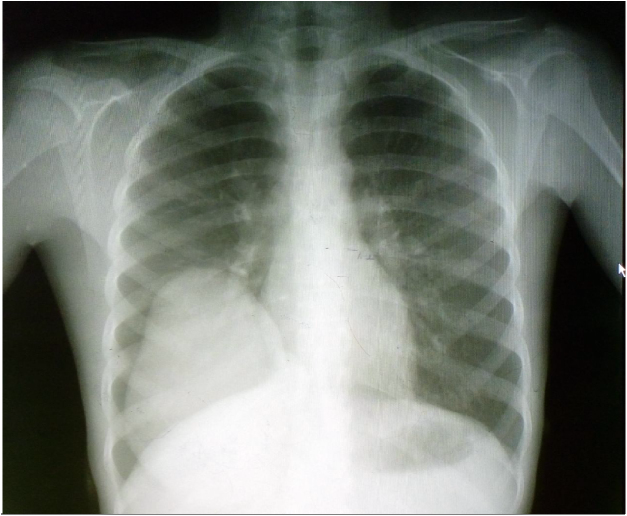

In [28]:

img=cv2.imread(img_path)
img

In [29]:
img.shape

(516, 627, 3)

array([[[255, 255, 255],
        [104, 103, 103],
        [103, 103, 103],
        ...,
        [100, 100, 100],
        [ 99,  99,  99],
        [187, 187, 187]],

       [[255, 255, 255],
        [ 14,  12,  12],
        [ 12,  10,  10],
        ...,
        [  8,   8,   8],
        [  6,   6,   6],
        [146, 146, 146]],

       [[255, 255, 255],
        [ 12,  10,  10],
        [ 12,  10,  10],
        ...,
        [  5,   5,   5],
        [  4,   4,   4],
        [146, 146, 146]],

       ...,

       [[255, 255, 255],
        [ 29,  37,  12],
        [ 28,  35,  13],
        ...,
        [ 13,  14,   1],
        [ 10,   6,   3],
        [148, 146, 145]],

       [[239, 239, 239],
        [ 29,  38,  11],
        [ 26,  34,  10],
        ...,
        [ 15,  16,   3],
        [  8,   4,   2],
        [149, 147, 146]],

       [[186, 186, 187],
        [176, 176, 176],
        [176, 176, 175],
        ...,
        [176, 176, 176],
        [177, 175, 175],
        [254, 254, 254]]], dtype=uint8)
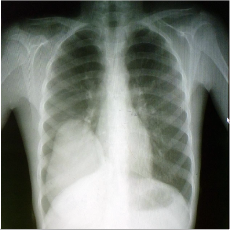

In [30]:
target_size=(230,230)
cv2.resize(img,target_size)

array([[255, 255, 255, ..., 255, 255, 255],
       [254, 255, 133, ...,   4, 128, 255],
       [255, 255, 132, ...,   4, 130, 254],
       ...,
       [254, 128,  78, ...,   4, 129, 255],
       [255, 127, 128, ..., 127, 254, 255],
       [254, 255, 254, ..., 255, 255, 255]], dtype=uint8)
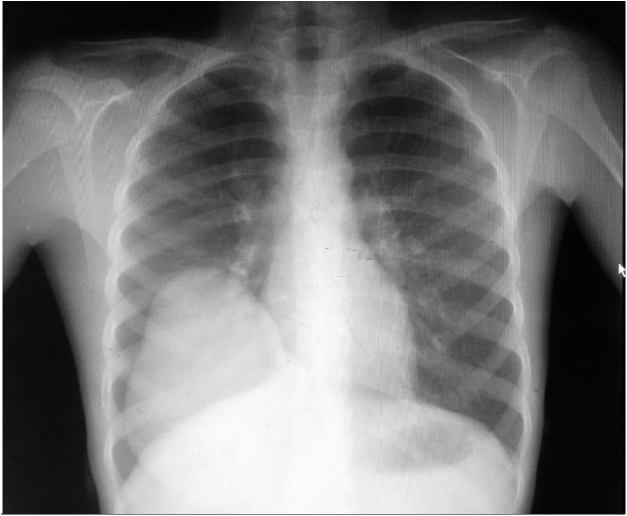

In [31]:
img_processed=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_processed


In [32]:

img_normalised=img/255
img_normalised

array([[[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       [[0.99607843, 0.99607843, 0.99607843],
        [1.        , 1.        , 1.        ],
        [0.52156863, 0.52156863, 0.52156863],
        ...,
        [0.02352941, 0.01568627, 0.01568627],
        [0.50196078, 0.50196078, 0.50196078],
        [1.        , 1.        , 1.        ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [0.51764706, 0.51764706, 0.51764706],
        ...,
        [0.02352941, 0.01568627, 0.01568627],
        [0.50980392, 0.50980392, 0.50980392],
        [0.99607843, 0.99607843, 0.99607843]],

       ...,

       [[0.99607843, 0.99607843, 0.99607843],
        [0.50196078, 0.50196078, 0.50196078],
        [0.30588235, 0

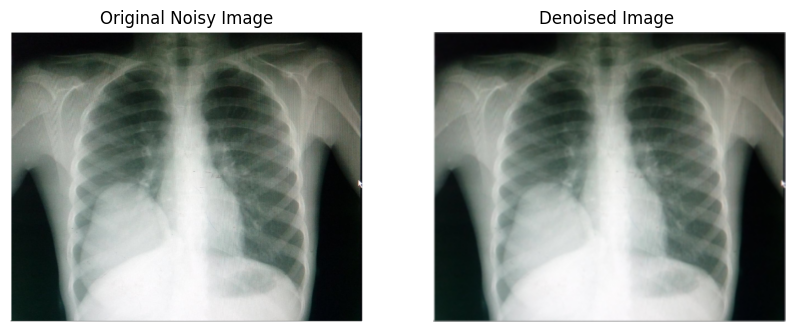

In [33]:
import cv2
import matplotlib.pyplot as plt


image_files=[f for f in os.listdir(img_dir) if f.endswith(".jpg")]

img=os.path.join(img_dir,image_files[50])
# Read the noisy image
image = cv2.imread(img)

# Check if the image was loaded successfully
if image is None:
    print("Error: Image not found or path is incorrect.")
else:
    # Apply Gaussian Blur (Denoising)
    denoised_image = cv2.GaussianBlur(image, (5, 5), 0)

    # Display the original and denoised image
    plt.figure(figsize=(10, 5))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Noisy Image')
    plt.axis('off')

    # Denoised Image
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(denoised_image, cv2.COLOR_BGR2RGB))
    plt.title('Denoised Image ')
    plt.axis('off')

    plt.show()

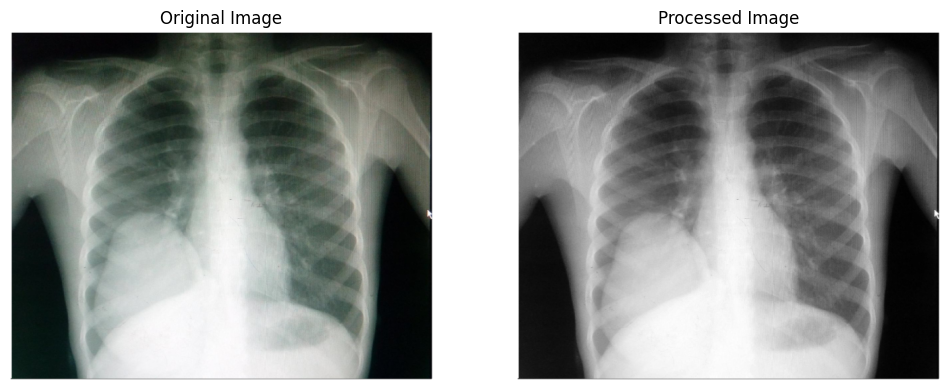

In [34]:

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
img_original = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Processed Image (Grayscale & Normalized)
plt.subplot(1, 2, 2)
plt.imshow(img_processed.squeeze(), cmap='gray')
plt.title('Processed Image')
plt.axis('off')



plt.show()


In [35]:


in_channel = 3
num_classes = 2
learning_rate = 3e-4
batch_size = 64
num_epochs = 15

In [36]:
import torchvision.transforms as transforms
import torchvision.transforms as transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [37]:
from torch.utils.data import Dataset, DataLoader
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        # Create a label map (assuming 'label' column in dataframe)
        self.label_map = {label: idx for idx, label in enumerate(dataframe['label'].unique())}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.iloc[idx, 4]  # Assuming image path is in the first column
        label = self.dataframe.iloc[idx, 2]  # Assuming label is in the second column

        # Convert label to numerical using label_map
        label = self.label_map[label]

        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Assuming you have a 'caption' column in your dataframe:
        caption = self.dataframe.iloc[idx, 1]

        return image, label, caption


TRAIN, TEST DATAFRAMES

In [38]:
train_df = data[data['Split'] == 'train'].reset_index(drop=True)
validation_df = data[data['Split'] == 'validation'].reset_index(drop=True)
test_df = data[data['Split'] == 'test'].reset_index(drop=True)

TRAIN,TEST DATASET

In [39]:
print(train_df.columns)
print(validation_df.columns)
print(test_df.columns)


Index(['image_id', 'Caption', 'Label', 'Split'], dtype='object')
Index(['image_id', 'Caption', 'Label', 'Split'], dtype='object')
Index(['image_id', 'Caption', 'Label', 'Split'], dtype='object')


In [40]:
train_df.rename(columns={'Label': 'label'}, inplace=True)
validation_df.rename(columns={'Label': 'label'}, inplace=True)
test_df.rename(columns={'Label': 'label'}, inplace=True)


In [41]:
train_dataset = CustomImageDataset(dataframe=train_df, transform=train_transform)
validation_dataset = CustomImageDataset(dataframe=validation_df, transform=eval_transform)
test_dataset = CustomImageDataset(dataframe=test_df, transform=eval_transform)

FOR LOADING DATA IN TRAIN ,TEST

In [42]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=50,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last= False
)
validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size=50,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last= False
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=50,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last= False
)

DATA AUGMENTAION

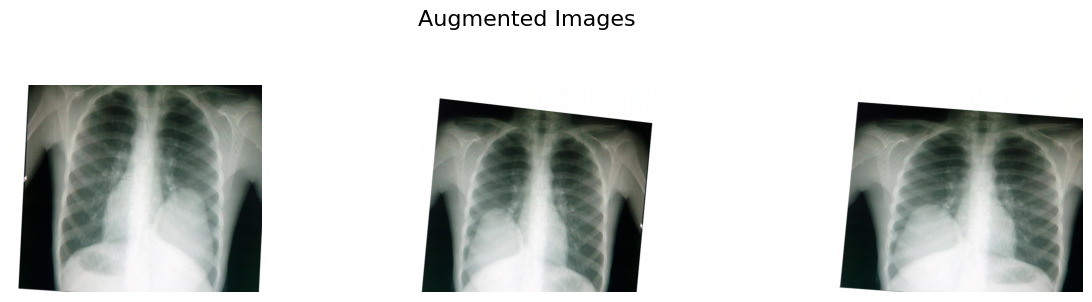

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import matplotlib.pyplot as plt

# Set up your augmentation configuration
datagen = ImageDataGenerator(
    rotation_range=15,              # Rotate images by up to 15 degrees
    width_shift_range=0.1,          # Shift image width by 10%
    height_shift_range=0.1,         # Shift image height by 10%
    shear_range=0.1,                # Shear by 10%
    zoom_range=0.2,                 # Zoom by up to 20%
    horizontal_flip=True,           # Flip horizontally
    fill_mode='nearest'             # Fill in new pixels with nearest value
)

def visualize_augmentation(img_path, num_augmented_images=5):
    """Display a specified number of augmented images for a single image."""
    img = load_img(img_path)  # Load the image
    img_array = img_to_array(img)  # Convert to array
    img_array = img_array.reshape((1,) + img_array.shape)  # Reshape for ImageDataGenerator

    # Set up the plot
    fig, axes = plt.subplots(1, num_augmented_images, figsize=(15, 3))
    fig.suptitle("Augmented Images", fontsize=16, y=1.05)

    # Adjust layout to remove excessive white space
    plt.subplots_adjust(top=0.8, hspace=0.2, wspace=0.2)

    # Generate and display augmented images
    i = 0
    for batch in datagen.flow(img_array, batch_size=1):
        ax = axes[i]
        ax.imshow(batch[0].astype('uint8'))
        ax.axis('off')
        i += 1
        if i >= num_augmented_images:  # Display only the specified number of images
            break

    plt.show()

# Example usage:
# Visualize augmentations for one image

visualize_augmentation(img_path, num_augmented_images=3)

Displaying a batch from train_loader:


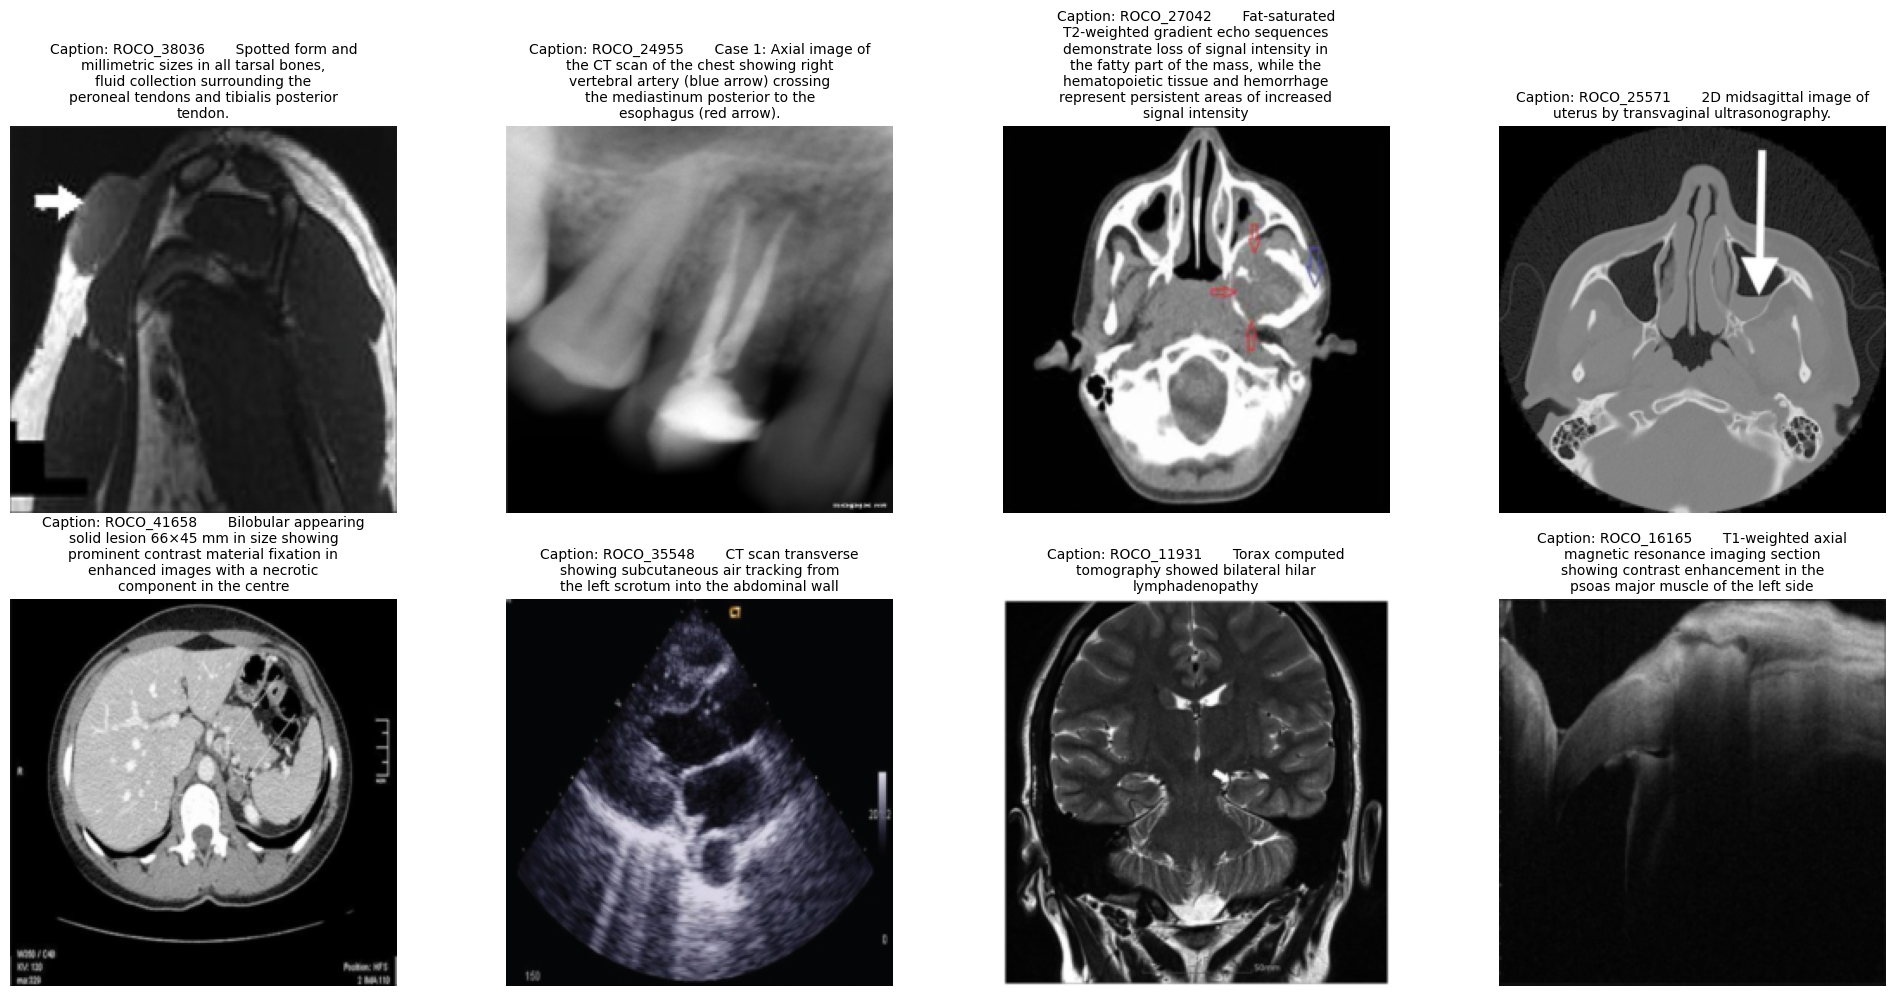

In [44]:
import os
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import textwrap

# Define a custom dataset for ROCO
class RocoDataset(Dataset):
    def __init__(self, image_dir, caption_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # Load captions from a text file
        with open(caption_file, 'r') as f:
            self.captions = f.readlines()

        # Assuming captions and image filenames are in the same order
        self.image_filenames = sorted(os.listdir(image_dir))  # Ensure correct order

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        # Load the image
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        image = Image.open(img_path).convert('RGB')

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Get the caption (strip any trailing newlines or spaces)
        caption = self.captions[idx].strip()
        return image, caption

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224 for uniformity
    transforms.ToTensor(),         # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

# Initialize the dataset and dataloader
image_dir = '/content/drive/MyDrive/ROCO/data/train/radiology/images'
caption_file = '/content/drive/MyDrive/ROCO/data/train/radiology/captions.txt'
roco_dataset = RocoDataset(image_dir, caption_file, transform=transform)
train_loader = DataLoader(roco_dataset, batch_size=8, shuffle=True)

# Denormalize images for visualization
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    tensor = tensor * std[:, None, None] + mean[:, None, None]
    return tensor.permute(1, 2, 0).clamp(0, 1).numpy()

# Visualize a batch of images
def show_batch_images(data_loader):
    data_iter = iter(data_loader)
    images, captions = next(data_iter)

    num_images = images.shape[0]
    cols = 4
    rows = (num_images // cols) + (num_images % cols > 0)

    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(20, rows * 5))
    axes = axes.flatten()

    for i in range(num_images):
        image = denormalize_image(images[i])
        axes[i].imshow(image)
        wrapped_caption = textwrap.fill(captions[i], width=40)
        axes[i].set_title(f"Caption: {wrapped_caption}", fontsize=10)
        axes[i].axis('off')

    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Display a batch of images
print("Displaying a batch from train_loader:")
show_batch_images(train_loader)


NLP PREPROCESSING

In [45]:

import pandas as pd


caption_data= pd.read_table('/content/drive/MyDrive/ROCO/data/train/radiology/captions.txt')
caption_data


,ROCO_00002,Computed tomography scan in axial view showing obliteration of the left maxillary sinus
0,ROCO_00003,Bacterial contamination occurred after comple...
1,ROCO_00004,The patient had residual paralysis of the han...
2,ROCO_00005,Panoramic radiograph after immediate loading.
3,ROCO_00007,Plain abdomen x-ray: Multiple air levels at t...
4,ROCO_00008,A 3-year-old child with visual difficulties. ...
...,...,...
65444,ROCO_81819,Initial CT abdomen with contrast showing a di...
65445,ROCO_81820,44-year-old male patient after surgical amput...
65446,ROCO_81821,Primary pulmonary tuberculosis in 18-year-old...
65447,ROCO_81822,"MRI brain with gadolinium, coronal view, show..."


In [46]:


import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
from nltk.stem import SnowballStemmer

In [47]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
snowballstemmer=SnowballStemmer('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [48]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [49]:
def preprocess_caption(caption_data):
    # Lowercase
    caption_data = caption_data.lower()

    # Remove punctuation
    caption = re.sub(f"[{string.punctuation}]", "", caption_data)

    # Tokenize
    tokens = word_tokenize(caption_data)

    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    #stemming
    tokens= [snowballstemmer.stem(word) for word in tokens]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a cleaned caption
    cleaned_caption = " ".join(tokens)
    return cleaned_caption

In [50]:
train_df['cleaned_caption'] = train_df['Caption'].apply(preprocess_caption)
validation_df['cleaned_caption'] = validation_df['Caption'].apply(preprocess_caption)


In [51]:
train_df['Caption'].head(5)


,Caption
0,Computed tomography scan in axial view showing...
1,Bacterial contamination occurred after complet...
2,The patient had residual paralysis of the hand...
3,Panoramic radiograph after immediate loading.
4,Plain abdomen x-ray: Multiple air levels at th...


In [52]:
train_df['cleaned_caption'].head(5)


,cleaned_caption
0,comput tomographi scan axial view show obliter...
1,bacteri contamin occur complet root canal trea...
2,patient residu paralysi hand poliomyel . neces...
3,panoram radiograph immedi load .
4,plain abdomen x-ray : multipl air level mid-ab...


STEMMING

In [53]:

from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [54]:

words=['eating','eats','eaten','writing','writes','programming']
for word in words:
  print(word,"......"+ps.stem(word))

eating ......eat
eats ......eat
eaten ......eaten
writing ......write
writes ......write
programming ......program


In [55]:
keywords_df=pd.read_table("/content/drive/MyDrive/ROCO/data/train/radiology/keywords.txt",header=None,names=['image_id','col1','reason','body_part','element','disease','col2','col3','col4','col5','col6'],sep="\t",on_bad_lines='skip')
keywords_df

,image_id,col1,reason,body_part,element,disease,col2,col3,col4,col5,col6
0,ROCO_00002,NaN,scan,maxillary,sinu,axial,tomography,obliteration,view,left,NaN
1,ROCO_00005,NaN,panoramic,loading,immediate,radiograph,NaN,NaN,NaN,NaN,NaN
2,ROCO_00007,NaN,multiple,radiopaque,level,diaphragm,plain,air,abdoman,shadow,midabdoman
3,ROCO_00009,NaN,porotic,subtrochanteric,fracture,bone,NaN,NaN,NaN,NaN,NaN
4,ROCO_00010,NaN,canal,root,maxillary,orthodontic,treatment,therapy,post,incisor,NaN
...,...,...,...,...,...,...,...,...,...,...,...
33559,ROCO_81803,NaN,xray,previou,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33560,ROCO_81807,NaN,body,canal,compression,burst,expansion,vertebral,fracture,l1,hemangioma
33561,ROCO_81811,NaN,interstitial,scan,presence,basal,lung,infiltrate,NaN,NaN,NaN
33562,ROCO_81815,NaN,tube,decompression,guidewire,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:

key_list=[]
for i in keywords_df['reason']:
  key_list.append(i)
key_list


['scan',
 'panoramic',
 'multiple',
 'porotic',
 'canal',
 'thrombi',
 'sonography',
 'coronary',
 'normal',
 'followup',
 'patient',
 'orthopantomograph',
 'parenchyma',
 'preoperative',
 'extension',
 'contrastenhanced',
 'pancreatic',
 'humeru',
 'evar',
 'control',
 'lesion',
 'postoperative',
 'control',
 'premolar',
 'cusp',
 'target',
 'abdominal',
 'drain',
 'mas',
 'metacarpal',
 'superior',
 'transverse',
 'hip',
 'proximal',
 'highsignal',
 'mas',
 'canal',
 'cerebral',
 'diameter',
 'right',
 'fragmentation',
 'barium',
 'angiography',
 'injury',
 'morphology',
 'anterior',
 'lesion',
 'aortic',
 'lesion',
 'mas',
 'neonatal',
 'magnetic',
 'point',
 'conventional',
 'visible',
 'patient',
 'mas',
 'ulna',
 'distal',
 'multiple',
 'foraman',
 'radiograph',
 'radiography',
 'orthopantomogram',
 'hip',
 'postoperative',
 'halovest',
 'right',
 'profile',
 'image',
 'image',
 'biphalangeal',
 'node',
 'brain',
 'anastomotic',
 'apexforming',
 'hip',
 'right',
 'placement',
 't

In [57]:
for i in key_list:
    if isinstance(i, str):  # Ensure the item is a string
        print(i, "......" + ps.stem(i))
    else:
        print(i, "...... Non-string value, skipping")


Streaming output truncated to the last 5000 lines.
tracheal ......tracheal
wall ......wall
abdominal ......abdomin
week ......week
control ......control
periapical ......periap
rectal ......rectal
origin ......origin
abdominal ......abdomin
adenoma ......adenoma
spine ......spine
arrowhead ......arrowhead
shoulder ......shoulder
case ......case
canal ......canal
patient ......patient
radiography ......radiographi
iopa ......iopa
greater ......greater
transgluteal ......transglut
barium ......barium
tendon ......tendon
image ......imag
cerebellar ......cerebellar
usg ......usg
cyst ......cyst
angiography ......angiographi
tomography ......tomographi
merkel ......merkel
diffusion ......diffus
exemplary ......exemplari
radiography ......radiographi
patient ......patient
mas ......ma
marsupialization ......marsupi
nonenhancing ......nonenhanc
catheter ......cathet
stomach ......stomach
multiple ......multipl
finding ......find
xray ......xray
twolevel ......twolevel
right ......right
widen

REGEXP STEMMER

In [58]:
from nltk.stem import RegexpStemmer
reg_stem = RegexpStemmer('ing$|s$|e$|able$', min=4)



In [59]:
for i in key_list:
    if isinstance(i, str):  # Ensure the item is a string
        print(i, "......" + reg_stem.stem(i))
    else:
        print(i, "...... Non-string value, skipping")


Streaming output truncated to the last 5000 lines.
tracheal ......tracheal
wall ......wall
abdominal ......abdominal
week ......week
control ......control
periapical ......periapical
rectal ......rectal
origin ......origin
abdominal ......abdominal
adenoma ......adenoma
spine ......spin
arrowhead ......arrowhead
shoulder ......shoulder
case ......cas
canal ......canal
patient ......patient
radiography ......radiography
iopa ......iopa
greater ......greater
transgluteal ......transgluteal
barium ......barium
tendon ......tendon
image ......imag
cerebellar ......cerebellar
usg ......usg
cyst ......cyst
angiography ......angiography
tomography ......tomography
merkel ......merkel
diffusion ......diffusion
exemplary ......exemplary
radiography ......radiography
patient ......patient
mas ......mas
marsupialization ......marsupialization
nonenhancing ......nonenhanc
catheter ......catheter
stomach ......stomach
multiple ......multipl
finding ......find
xray ......xray
twolevel ......twolevel

SNOWBALL STEMMER

In [60]:
from nltk.stem import SnowballStemmer
snow_stem=SnowballStemmer("english")



In [61]:
for i in key_list:
    if isinstance(i, str):  # Ensure the item is a string
        print(i, "......" + snow_stem.stem(i))
    else:
        print(i, "...... Non-string value, skipping")


Streaming output truncated to the last 5000 lines.
tracheal ......tracheal
wall ......wall
abdominal ......abdomin
week ......week
control ......control
periapical ......periap
rectal ......rectal
origin ......origin
abdominal ......abdomin
adenoma ......adenoma
spine ......spine
arrowhead ......arrowhead
shoulder ......shoulder
case ......case
canal ......canal
patient ......patient
radiography ......radiographi
iopa ......iopa
greater ......greater
transgluteal ......transglut
barium ......barium
tendon ......tendon
image ......imag
cerebellar ......cerebellar
usg ......usg
cyst ......cyst
angiography ......angiographi
tomography ......tomographi
merkel ......merkel
diffusion ......diffus
exemplary ......exemplari
radiography ......radiographi
patient ......patient
mas ......mas
marsupialization ......marsupi
nonenhancing ......nonenhanc
catheter ......cathet
stomach ......stomach
multiple ......multipl
finding ......find
xray ......xray
twolevel ......twolevel
right ......right
wide

In [62]:
from nltk import word_tokenize, pos_tag, ne_chunk


In [63]:
nltk.download('averaged_perceptron_tagger_eng')
nltk.download("maxent_ne_chunker")
nltk.download("words")
nltk.download("maxent_ne_chunker_tab")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [64]:
size = train_df['cleaned_caption'].size
print(size)


70345


In [69]:


new_df = train_df.sample(n=100, random_state=42)


In [70]:
ner_caption = []

for caption in new_df['cleaned_caption']:
    tokens = word_tokenize(caption)  # Tokenize the caption
    tags = nltk.pos_tag(tokens)      # POS tagging is needed for NER
    entities = nltk.ne_chunk(tags)  # Get NER tags
    ner_caption.append(entities)

In [71]:
ner_caption

[Tree('S', [('supraglott', 'NN'), ('scc', 'NN'), ('–', 'NN'), ('fals', 'NNS'), ('cord', 'NN'), ('.', '.'), ('axial', 'JJ'), ('contrast', 'NN'), ('ct', 'NN'), ('section', 'NN'), ('fals', 'NNS'), ('cord', 'VBP'), ('show', 'NN'), ('mass', 'NN'), ('within', 'IN'), ('right', 'JJ'), ('fals', 'NNS'), ('cord', 'VBP'), ('invad', 'RB'), ('right', 'JJ'), ('pgs', 'NN'), ('(', '('), ('black', 'JJ'), ('asterisk', 'NN'), (')', ')')]),
 Tree('S', [('postretent', 'NN'), ('later', 'RB'), ('cephalometr', 'JJ'), ('radiograph', 'NN'), ('distractor', 'NN'), ('remov', 'VBD'), ('3', 'CD'), ('month', 'NN'), ('follow', 'JJ'), ('complet', 'NN'), ('distract', 'NN'), ('.', '.'), ('intern', 'JJ'), ('fixat', 'JJ'), ('devic', 'JJ'), ('appli', 'NN'), ('long-term', 'JJ'), ('retent', 'NN'), (',', ','), ('dental', 'JJ'), ('implant', 'JJ'), ('place', 'NN'), ('anterior', 'JJ'), ('incis', 'JJ'), ('align', 'NN'), ('normal', 'JJ')]),
 Tree('S', [('trace', 'NN'), ('bacteri', 'NN'), ('contamin', 'NN'), ('found', 'VBD'), ('titan

In [72]:
# Randomly select 20 captions
random_captions = train_df['cleaned_caption'].sample(n=100, random_state=42)

# Combine the selected captions into a single paragraph
combined_captions = " ".join(random_captions)

print(combined_captions)

supraglott scc – fals cord . axial contrast ct section fals cord show mass within right fals cord invad right pgs ( black asterisk ) postretent later cephalometr radiograph distractor remov 3 month follow complet distract . intern fixat devic appli long-term retent , dental implant place anterior incis align normal trace bacteri contamin found titanium disc treat argon plasma chamber , irrespect implant surfac test . ct scan patient non-contrast enhanc ct scan done 3 year prior misidentif duplic ivc enlarg left gonad vein . pre-aort trunk ( white arrow ) aorta ( black arrow ) . ultrasound imag needl shaft short axi phantom model . open mouth saggit section ct scan ( right ) ct scan chest intim flap separ true fals lumen , mural thrombus near intim flap , aneurysm ascend thorac aorta approxim 11 cm diamet , pleural effus right hemithorax . follow 7 day antibiot therapi , small nodular lesion ( black arrow ) observ follow-up comput tomographi scan imag , irregular mass disappear . orthop

cleaning text

In [73]:

combined_captions = combined_captions.lower()

In [74]:

print(combined_captions)

supraglott scc – fals cord . axial contrast ct section fals cord show mass within right fals cord invad right pgs ( black asterisk ) postretent later cephalometr radiograph distractor remov 3 month follow complet distract . intern fixat devic appli long-term retent , dental implant place anterior incis align normal trace bacteri contamin found titanium disc treat argon plasma chamber , irrespect implant surfac test . ct scan patient non-contrast enhanc ct scan done 3 year prior misidentif duplic ivc enlarg left gonad vein . pre-aort trunk ( white arrow ) aorta ( black arrow ) . ultrasound imag needl shaft short axi phantom model . open mouth saggit section ct scan ( right ) ct scan chest intim flap separ true fals lumen , mural thrombus near intim flap , aneurysm ascend thorac aorta approxim 11 cm diamet , pleural effus right hemithorax . follow 7 day antibiot therapi , small nodular lesion ( black arrow ) observ follow-up comput tomographi scan imag , irregular mass disappear . orthop

STOPWORDS GENERATION

In [75]:
from nltk.corpus import stopwords

import nltk
nltk.download("stopwords")
stop_words=set(stopwords.words('english'))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [76]:
print(stop_words)


{"needn't", 'that', 'yourselves', "mightn't", 'why', 'yours', 'ours', 'be', 'how', 'haven', 'having', 'these', 'are', 'about', 'own', "you'll", 'themselves', 'mightn', 'not', "weren't", 'hadn', 'whom', 'off', 'few', 'while', 'won', 'had', 'when', 'who', 'again', 'a', 'between', 'each', 'after', 'same', "it's", "that'll", 'other', 'on', 'shouldn', 'aren', 'before', 'she', 'in', "hasn't", "you've", 'my', 'itself', 'more', 'because', 'does', 'here', 'couldn', 'what', 'doing', 's', 'll', 'wasn', 'hasn', 'ma', 'its', 'under', 'them', 'did', 'now', 'up', 'further', "didn't", "she's", 'but', 'was', 'over', 'herself', 'such', 're', 'during', 'wouldn', "hadn't", 'theirs', 'and', 'than', 'no', 'it', "should've", 'so', 'they', 'our', 'been', 'should', 'against', 'doesn', 'all', 'nor', 'mustn', 'of', "you'd", 'is', 'am', 'any', 'to', "shouldn't", 'into', "aren't", 'or', 'shan', 'once', "doesn't", 'has', 'too', "couldn't", 'were', "wasn't", 'd', 'their', 've', 'yourself', 'out', 'hers', 'just', 'wh

In [77]:
stop_word=" ".join([word for word in combined_captions.split() if word not in stop_words])
print(stop_word)



supraglott scc – fals cord . axial contrast ct section fals cord show mass within right fals cord invad right pgs ( black asterisk ) postretent later cephalometr radiograph distractor remov 3 month follow complet distract . intern fixat devic appli long-term retent , dental implant place anterior incis align normal trace bacteri contamin found titanium disc treat argon plasma chamber , irrespect implant surfac test . ct scan patient non-contrast enhanc ct scan done 3 year prior misidentif duplic ivc enlarg left gonad vein . pre-aort trunk ( white arrow ) aorta ( black arrow ) . ultrasound imag needl shaft short axi phantom model . open mouth saggit section ct scan ( right ) ct scan chest intim flap separ true fals lumen , mural thrombus near intim flap , aneurysm ascend thorac aorta approxim 11 cm diamet , pleural effus right hemithorax . follow 7 day antibiot therapi , small nodular lesion ( black arrow ) observ follow-up comput tomographi scan imag , irregular mass disappear . orthop

In [78]:
pip install textblob


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.3/626.3 kB 7.6 MB/s eta 0:00:00


In [79]:
from textblob import TextBlob


In [80]:
TextBlob(combined_captions).correct()


TextBlob("supraglott sac – fall cord . animal contrast it section fall cord show mass within right fall cord invade right pus ( black asterisk ) postretent later cephalometr radiogram distracted remove 3 month follow complete distract . inter fiat devil apply long-term recent , dental plant place anterior incise align normal trace bacteria contain found titanic disc treat arson plasma chamber , respect plant surface test . it scan patient non-contrast enhance it scan done 3 year prior misidentif public iv enlarge left good vein . pre-sort trunk ( white arrow ) aorta ( black arrow ) . ultrasound image need shaft short axis phantom model . open mouth sait section it scan ( right ) it scan chest intima flap spear true fall lumen , murat thrombus near intima flap , aneurysm ascend thorax aorta approxim 11 cm diet , pleural effused right hemithorax . follow 7 day antibiot therapy , small nodular lesion ( black arrow ) observe follow-up compute tomographi scan image , irregular mass disappea

TEXT TOKENIZATION

In [81]:
from nltk.tokenize import sent_tokenize
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [82]:
combined_caption = sent_tokenize(combined_captions)

sent_tokenize(combined_captions)

['supraglott scc – fals cord .',
 'axial contrast ct section fals cord show mass within right fals cord invad right pgs ( black asterisk ) postretent later cephalometr radiograph distractor remov 3 month follow complet distract .',
 'intern fixat devic appli long-term retent , dental implant place anterior incis align normal trace bacteri contamin found titanium disc treat argon plasma chamber , irrespect implant surfac test .',
 'ct scan patient non-contrast enhanc ct scan done 3 year prior misidentif duplic ivc enlarg left gonad vein .',
 'pre-aort trunk ( white arrow ) aorta ( black arrow ) .',
 'ultrasound imag needl shaft short axi phantom model .',
 'open mouth saggit section ct scan ( right ) ct scan chest intim flap separ true fals lumen , mural thrombus near intim flap , aneurysm ascend thorac aorta approxim 11 cm diamet , pleural effus right hemithorax .',
 'follow 7 day antibiot therapi , small nodular lesion ( black arrow ) observ follow-up comput tomographi scan imag , irr

In [83]:
!pip install nltk spacy scikit-learn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 23.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [84]:
import spacy

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")



# Process the text
doc = nlp(combined_captions)

# POS Tagging
pos_tags = [(token.text, token.pos_) for token in doc]
print("POS Tags:", pos_tags)

# Named Entity Recognition (NER)
ner_tags = [(ent.text, ent.label_) for ent in doc.ents]
print("Named Entities:", ner_tags)

POS Tags: [('supraglott', 'PROPN'), ('scc', 'PROPN'), ('–', 'PUNCT'), ('fals', 'NOUN'), ('cord', 'NOUN'), ('.', 'PUNCT'), ('axial', 'ADJ'), ('contrast', 'NOUN'), ('ct', 'PROPN'), ('section', 'NOUN'), ('fals', 'NOUN'), ('cord', 'PROPN'), ('show', 'VERB'), ('mass', 'NOUN'), ('within', 'ADP'), ('right', 'ADJ'), ('fals', 'NOUN'), ('cord', 'NOUN'), ('invad', 'PROPN'), ('right', 'ADJ'), ('pgs', 'NOUN'), ('(', 'PUNCT'), ('black', 'ADJ'), ('asterisk', 'NOUN'), (')', 'PUNCT'), ('postretent', 'NOUN'), ('later', 'ADJ'), ('cephalometr', 'PROPN'), ('radiograph', 'NOUN'), ('distractor', 'PROPN'), ('remov', 'PROPN'), ('3', 'NUM'), ('month', 'NOUN'), ('follow', 'NOUN'), ('complet', 'NOUN'), ('distract', 'PROPN'), ('.', 'PUNCT'), ('intern', 'PROPN'), ('fixat', 'PROPN'), ('devic', 'PROPN'), ('appli', 'PROPN'), ('long', 'ADJ'), ('-', 'PUNCT'), ('term', 'NOUN'), ('retent', 'NOUN'), (',', 'PUNCT'), ('dental', 'ADJ'), ('implant', 'ADJ'), ('place', 'NOUN'), ('anterior', 'ADJ'), ('incis', 'PROPN'), ('align', 

In [85]:

import spacy

# Load the spaCy model for NER
nlp = spacy.load("en_core_web_sm")



# Apply NER
doc = nlp(combined_captions)
for ent in doc.ents:
    print(f"Entity: {ent.text}, Label: {ent.label_}")

Entity: supraglott scc, Label: PERSON
Entity: 3 month, Label: DATE
Entity: appli long-term, Label: PERSON
Entity: scan, Label: NORP
Entity: scan, Label: NORP
Entity: 3 year, Label: DATE
Entity: gonad vein, Label: PERSON
Entity: aorta, Label: PERSON
Entity: saggit, Label: DATE
Entity: 11 cm, Label: QUANTITY
Entity: 7 day, Label: DATE
Entity: scan, Label: NORP
Entity: maxillari mucocel, Label: ORG
Entity: linear-array, Label: ORG
Entity: eu imag direct celiac, Label: PERSON
Entity: appar second, Label: PERSON
Entity: 17 cm, Label: QUANTITY
Entity: arrow indic area, Label: PERSON
Entity: 1 mm, Label: QUANTITY
Entity: intramedullari cord, Label: PERSON
Entity: chang, Label: PERSON
Entity: 12-week, Label: DATE
Entity: correspond deliveri sinogram, Label: PERSON
Entity: 6mo, Label: ORDINAL
Entity: 3-d, Label: TIME
Entity: grey valu interpol, Label: ORG
Entity: primari, Label: ORG
Entity: four, Label: CARDINAL
Entity: 0.1 mm, Label: QUANTITY
Entity: intestin loop, Label: ORG
Entity: arrow ind

In [86]:
from sklearn.feature_extraction.text import CountVectorizer



# Create a BoG model
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(combined_caption)

# Display the vocabulary and the document-term matrix
print("Vocabulary:", vectorizer.vocabulary_)
print("Document-Term Matrix:\n", X.toarray())

Vocabulary: {'supraglott': 641, 'scc': 585, 'fals': 247, 'cord': 147, 'axial': 69, 'contrast': 144, 'ct': 157, 'section': 588, 'show': 607, 'mass': 396, 'within': 721, 'right': 568, 'invad': 339, 'pgs': 494, 'black': 82, 'asterisk': 62, 'postretent': 526, 'later': 360, 'cephalometr': 111, 'radiograph': 544, 'distractor': 191, 'remov': 559, 'month': 422, 'follow': 261, 'complet': 129, 'distract': 190, 'intern': 330, 'fixat': 254, 'devic': 180, 'appli': 50, 'long': 382, 'term': 653, 'retent': 564, 'dental': 173, 'implant': 313, 'place': 503, 'anterior': 36, 'incis': 316, 'align': 26, 'normal': 448, 'trace': 676, 'bacteri': 71, 'contamin': 142, 'found': 266, 'titanium': 670, 'disc': 188, 'treat': 682, 'argon': 54, 'plasma': 508, 'chamber': 113, 'irrespect': 343, 'surfac': 642, 'test': 654, 'scan': 583, 'patient': 481, 'non': 447, 'enhanc': 224, 'done': 194, 'year': 722, 'prior': 537, 'misidentif': 416, 'duplic': 210, 'ivc': 346, 'enlarg': 225, 'left': 365, 'gonad': 277, 'vein': 706, 'pre'

In [87]:
from nltk.tokenize import wordpunct_tokenize

wordpunct_tokenize(combined_captions)

['supraglott',
 'scc',
 '–',
 'fals',
 'cord',
 '.',
 'axial',
 'contrast',
 'ct',
 'section',
 'fals',
 'cord',
 'show',
 'mass',
 'within',
 'right',
 'fals',
 'cord',
 'invad',
 'right',
 'pgs',
 '(',
 'black',
 'asterisk',
 ')',
 'postretent',
 'later',
 'cephalometr',
 'radiograph',
 'distractor',
 'remov',
 '3',
 'month',
 'follow',
 'complet',
 'distract',
 '.',
 'intern',
 'fixat',
 'devic',
 'appli',
 'long',
 '-',
 'term',
 'retent',
 ',',
 'dental',
 'implant',
 'place',
 'anterior',
 'incis',
 'align',
 'normal',
 'trace',
 'bacteri',
 'contamin',
 'found',
 'titanium',
 'disc',
 'treat',
 'argon',
 'plasma',
 'chamber',
 ',',
 'irrespect',
 'implant',
 'surfac',
 'test',
 '.',
 'ct',
 'scan',
 'patient',
 'non',
 '-',
 'contrast',
 'enhanc',
 'ct',
 'scan',
 'done',
 '3',
 'year',
 'prior',
 'misidentif',
 'duplic',
 'ivc',
 'enlarg',
 'left',
 'gonad',
 'vein',
 '.',
 'pre',
 '-',
 'aort',
 'trunk',
 '(',
 'white',
 'arrow',
 ')',
 'aorta',
 '(',
 'black',
 'arrow',
 ')',

BAG OF WORDS

In [88]:

from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100,binary=True)


In [89]:
captions = ["Exocranial aspect of skull base showing attachment of deep neck spaces to skull base"," Caption: ROCO 43874 Contrast-enhanced CT performed 5 days later shows the disappearance of the PAP ."]


In [90]:
X=cv.fit_transform(captions)


In [91]:
X.toarray()


array([[0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
        0, 1],
       [1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 0]])

In [92]:
cv.get_feature_names_out()

array(['43874', 'aspect', 'attachment', 'base', 'caption', 'contrast',
       'ct', 'days', 'deep', 'disappearance', 'enhanced', 'exocranial',
       'later', 'neck', 'of', 'pap', 'performed', 'roco', 'showing',
       'shows', 'skull', 'spaces', 'the', 'to'], dtype=object)

In [93]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100,binary=True,ngram_range=(2,3))

In [94]:
x=cv.fit_transform(captions).toarray()
x

array([[0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
        1, 1, 0, 0, 0, 1, 1],
       [1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
        0, 0, 1, 1, 1, 0, 0]])

In [96]:
cv.get_feature_names_out()

array(['43874 contrast', '43874 contrast enhanced', 'aspect of',
       'aspect of skull', 'attachment of', 'attachment of deep',
       'base showing', 'base showing attachment', 'caption roco',
       'caption roco 43874', 'contrast enhanced', 'contrast enhanced ct',
       'ct performed', 'ct performed days', 'days later',
       'days later shows', 'deep neck', 'deep neck spaces',
       'disappearance of', 'disappearance of the', 'enhanced ct',
       'enhanced ct performed', 'exocranial aspect',
       'exocranial aspect of', 'later shows', 'later shows the',
       'neck spaces', 'neck spaces to', 'of deep', 'of deep neck',
       'of skull', 'of skull base', 'of the', 'of the pap',
       'performed days', 'performed days later', 'roco 43874',
       'roco 43874 contrast', 'showing attachment',
       'showing attachment of', 'shows the', 'shows the disappearance',
       'skull base', 'skull base showing', 'spaces to', 'spaces to skull',
       'the disappearance', 'the disapp

In [97]:
cv.vocabulary_

{'exocranial aspect': 22,
 'aspect of': 2,
 'of skull': 30,
 'skull base': 42,
 'base showing': 6,
 'showing attachment': 38,
 'attachment of': 4,
 'of deep': 28,
 'deep neck': 16,
 'neck spaces': 26,
 'spaces to': 44,
 'to skull': 49,
 'exocranial aspect of': 23,
 'aspect of skull': 3,
 'of skull base': 31,
 'skull base showing': 43,
 'base showing attachment': 7,
 'showing attachment of': 39,
 'attachment of deep': 5,
 'of deep neck': 29,
 'deep neck spaces': 17,
 'neck spaces to': 27,
 'spaces to skull': 45,
 'to skull base': 50,
 'caption roco': 8,
 'roco 43874': 36,
 '43874 contrast': 0,
 'contrast enhanced': 10,
 'enhanced ct': 20,
 'ct performed': 12,
 'performed days': 34,
 'days later': 14,
 'later shows': 24,
 'shows the': 40,
 'the disappearance': 46,
 'disappearance of': 18,
 'of the': 32,
 'the pap': 48,
 'caption roco 43874': 9,
 'roco 43874 contrast': 37,
 '43874 contrast enhanced': 1,
 'contrast enhanced ct': 11,
 'enhanced ct performed': 21,
 'ct performed days': 13,
 

In [98]:

cv.vocabulary_

{'exocranial aspect': 22,
 'aspect of': 2,
 'of skull': 30,
 'skull base': 42,
 'base showing': 6,
 'showing attachment': 38,
 'attachment of': 4,
 'of deep': 28,
 'deep neck': 16,
 'neck spaces': 26,
 'spaces to': 44,
 'to skull': 49,
 'exocranial aspect of': 23,
 'aspect of skull': 3,
 'of skull base': 31,
 'skull base showing': 43,
 'base showing attachment': 7,
 'showing attachment of': 39,
 'attachment of deep': 5,
 'of deep neck': 29,
 'deep neck spaces': 17,
 'neck spaces to': 27,
 'spaces to skull': 45,
 'to skull base': 50,
 'caption roco': 8,
 'roco 43874': 36,
 '43874 contrast': 0,
 'contrast enhanced': 10,
 'enhanced ct': 20,
 'ct performed': 12,
 'performed days': 34,
 'days later': 14,
 'later shows': 24,
 'shows the': 40,
 'the disappearance': 46,
 'disappearance of': 18,
 'of the': 32,
 'the pap': 48,
 'caption roco 43874': 9,
 'roco 43874 contrast': 37,
 '43874 contrast enhanced': 1,
 'contrast enhanced ct': 11,
 'enhanced ct performed': 21,
 'ct performed days': 13,
 

TFI-DF

In [99]:
combined_cap=combined_caption[:10]


In [100]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [101]:
tfidf=TfidfVectorizer(max_features=100)
X=tfidf.fit_transform(combined_cap).toarray()

In [102]:
combined_cap


['supraglott scc – fals cord .',
 'axial contrast ct section fals cord show mass within right fals cord invad right pgs ( black asterisk ) postretent later cephalometr radiograph distractor remov 3 month follow complet distract .',
 'intern fixat devic appli long-term retent , dental implant place anterior incis align normal trace bacteri contamin found titanium disc treat argon plasma chamber , irrespect implant surfac test .',
 'ct scan patient non-contrast enhanc ct scan done 3 year prior misidentif duplic ivc enlarg left gonad vein .',
 'pre-aort trunk ( white arrow ) aorta ( black arrow ) .',
 'ultrasound imag needl shaft short axi phantom model .',
 'open mouth saggit section ct scan ( right ) ct scan chest intim flap separ true fals lumen , mural thrombus near intim flap , aneurysm ascend thorac aorta approxim 11 cm diamet , pleural effus right hemithorax .',
 'follow 7 day antibiot therapi , small nodular lesion ( black arrow ) observ follow-up comput tomographi scan imag , irr

In [103]:
X


array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.75262077, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.65845424, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [104]:
tfidf.vocabulary_


{'fals': 36,
 'cord': 21,
 'axial': 9,
 'contrast': 20,
 'ct': 22,
 'section': 90,
 'show': 91,
 'mass': 60,
 'within': 98,
 'right': 88,
 'invad': 51,
 'pgs': 79,
 'black': 10,
 'postretent': 84,
 'later': 55,
 'cephalometr': 12,
 'distractor': 30,
 'month': 64,
 'follow': 39,
 'complet': 16,
 'distract': 29,
 'intern': 48,
 'fixat': 37,
 'devic': 25,
 'appli': 7,
 'long': 58,
 'dental': 24,
 'implant': 44,
 'place': 81,
 'anterior': 3,
 'incis': 45,
 'align': 1,
 'normal': 72,
 'contamin': 19,
 'found': 40,
 'disc': 28,
 'plasma': 82,
 'chamber': 13,
 'irrespect': 53,
 'scan': 89,
 'patient': 77,
 'non': 71,
 'enhanc': 34,
 'done': 31,
 'year': 99,
 'prior': 86,
 'misidentif': 62,
 'duplic': 32,
 'ivc': 54,
 'enlarg': 35,
 'left': 56,
 'gonad': 41,
 'vein': 96,
 'pre': 85,
 'aort': 5,
 'trunk': 93,
 'white': 97,
 'arrow': 8,
 'aorta': 6,
 'ultrasound': 94,
 'imag': 43,
 'needl': 69,
 'phantom': 80,
 'model': 63,
 'open': 75,
 'mouth': 65,
 'chest': 14,
 'intim': 49,
 'flap': 38,
 'tr

WORD2VEC

In [105]:
!pip install gensim


In [106]:
from gensim.models import Word2Vec,KeyedVectors
import gensim.downloader as api
wv=api.load("word2vec-google-news-300")


[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [107]:
veec_FRA=wv["Fracture"]


In [108]:
veec_FRA


array([ 0.33203125, -0.17578125, -0.390625  , -0.07910156, -0.20703125,
        0.33984375, -0.13964844,  0.03125   , -0.18554688,  0.20117188,
        0.04833984,  0.24707031,  0.24902344, -0.07714844, -0.01525879,
        0.3359375 , -0.22949219,  0.04956055, -0.23828125,  0.25195312,
       -0.00331116,  0.1328125 ,  0.02185059,  0.33789062,  0.02319336,
       -0.20507812,  0.01220703,  0.27539062, -0.07910156, -0.29882812,
       -0.48828125, -0.05688477,  0.29492188, -0.43554688, -0.09082031,
        0.3359375 , -0.28515625,  0.07568359,  0.09082031, -0.10449219,
        0.25195312, -0.08837891, -0.24609375,  0.04272461, -0.03540039,
       -0.19335938,  0.07080078,  0.13476562,  0.17578125,  0.23046875,
       -0.26953125, -0.12304688, -0.484375  , -0.23828125,  0.3203125 ,
        0.07373047, -0.06933594, -0.1484375 ,  0.03271484,  0.24023438,
       -0.04443359,  0.28320312,  0.05639648, -0.21191406, -0.46679688,
       -0.15722656, -0.22949219,  0.01306152,  0.07910156, -0.04

In [109]:
wv.most_similar("radiograph")


[('radiographs', 0.7986594438552856),
 ('Radiographs', 0.7528969049453735),
 ('computed_tomographic_scan', 0.6952935457229614),
 ('lateral_radiographs', 0.6740736365318298),
 ('plain_radiographs', 0.672022819519043),
 ('lateral_radiograph', 0.6532841920852661),
 ('transvaginal_sonography', 0.6494017839431763),
 ('Computed_tomography', 0.6447806358337402),
 ('anteroposterior', 0.6446850895881653),
 ('radiographically', 0.6424738168716431)]

In [110]:
words=[]
for i in range(len(combined_cap)):
    words_=nltk.word_tokenize(combined_cap[i])
    words.append(words_)

words



[['supraglott', 'scc', '–', 'fals', 'cord', '.'],
 ['axial',
  'contrast',
  'ct',
  'section',
  'fals',
  'cord',
  'show',
  'mass',
  'within',
  'right',
  'fals',
  'cord',
  'invad',
  'right',
  'pgs',
  '(',
  'black',
  'asterisk',
  ')',
  'postretent',
  'later',
  'cephalometr',
  'radiograph',
  'distractor',
  'remov',
  '3',
  'month',
  'follow',
  'complet',
  'distract',
  '.'],
 ['intern',
  'fixat',
  'devic',
  'appli',
  'long-term',
  'retent',
  ',',
  'dental',
  'implant',
  'place',
  'anterior',
  'incis',
  'align',
  'normal',
  'trace',
  'bacteri',
  'contamin',
  'found',
  'titanium',
  'disc',
  'treat',
  'argon',
  'plasma',
  'chamber',
  ',',
  'irrespect',
  'implant',
  'surfac',
  'test',
  '.'],
 ['ct',
  'scan',
  'patient',
  'non-contrast',
  'enhanc',
  'ct',
  'scan',
  'done',
  '3',
  'year',
  'prior',
  'misidentif',
  'duplic',
  'ivc',
  'enlarg',
  'left',
  'gonad',
  'vein',
  '.'],
 ['pre-aort',
  'trunk',
  '(',
  'white',
  '

In [111]:
cbow_model=Word2Vec(words,vector_size=10,min_count=1,sg=0)
skipgram_model=Word2Vec(words,vector_size=10,min_count=1,sg=1)

In [112]:
cbow_model.wv["radiograph"]


array([ 0.09079285,  0.08934966, -0.08189912, -0.02993566,  0.09881765,
        0.05103675, -0.01562905, -0.08703966,  0.02934273, -0.06693534],
      dtype=float32)

VGG16 FEATURE MAP

In [113]:

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

In [114]:
base_model=VGG16(weights="imagenet")



553467096/553467096 [==============================] - 2s 0us/step


In [115]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer("block5_conv3").output)



In [116]:
def load_and_preprocess_image(img_path,target_size=(224,224)):
  img=image.load_img(r"/content/drive/MyDrive/ROCO/data/test/radiology/images/ROCO_00025.jpg",target_size=target_size)
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)
  img_array=preprocess_input(img_array)
  return img_array

In [117]:
img=image.load_img(r"/content/drive/MyDrive/ROCO/data/test/radiology/images/ROCO_00025.jpg",target_size=(224,224))
img_array=image.img_to_array(img)

img_array

array([[[252., 252., 252.],
        [255., 255., 255.],
        [254., 254., 254.],
        ...,
        [255., 255., 255.],
        [251., 251., 251.],
        [255., 254., 255.]],

       [[247., 247., 247.],
        [255., 255., 255.],
        [255., 255., 255.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [252., 250., 251.]],

       [[255., 255., 255.],
        [255., 255., 255.],
        [253., 253., 253.],
        ...,
        [255., 255., 255.],
        [252., 252., 252.],
        [255., 254., 255.]],

       ...,

       [[255., 255., 255.],
        [255., 255., 255.],
        [255., 255., 255.],
        ...,
        [255., 255., 255.],
        [255., 255., 255.],
        [255., 254., 255.]],

       [[255., 254., 255.],
        [255., 254., 255.],
        [255., 254., 255.],
        ...,
        [255., 255., 255.],
        [255., 255., 255.],
        [255., 254., 255.]],

       [[253., 251., 252.],
        [253., 251., 252.],
        [255., 2

In [118]:
import numpy as np
img_array=np.expand_dims(img_array,axis=0)
img_array



array([[[[252., 252., 252.],
         [255., 255., 255.],
         [254., 254., 254.],
         ...,
         [255., 255., 255.],
         [251., 251., 251.],
         [255., 254., 255.]],

        [[247., 247., 247.],
         [255., 255., 255.],
         [255., 255., 255.],
         ...,
         [254., 254., 254.],
         [254., 254., 254.],
         [252., 250., 251.]],

        [[255., 255., 255.],
         [255., 255., 255.],
         [253., 253., 253.],
         ...,
         [255., 255., 255.],
         [252., 252., 252.],
         [255., 254., 255.]],

        ...,

        [[255., 255., 255.],
         [255., 255., 255.],
         [255., 255., 255.],
         ...,
         [255., 255., 255.],
         [255., 255., 255.],
         [255., 254., 255.]],

        [[255., 254., 255.],
         [255., 254., 255.],
         [255., 254., 255.],
         ...,
         [255., 255., 255.],
         [255., 255., 255.],
         [255., 254., 255.]],

        [[253., 251., 252.],
       

In [119]:

img_array=preprocess_input(img_array)


img_array


array([[[[148.061  , 135.22101, 128.32   ],
         [151.061  , 138.22101, 131.32   ],
         [150.061  , 137.22101, 130.32   ],
         ...,
         [151.061  , 138.22101, 131.32   ],
         [147.061  , 134.22101, 127.32   ],
         [151.061  , 137.22101, 131.32   ]],

        [[143.061  , 130.22101, 123.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         ...,
         [150.061  , 137.22101, 130.32   ],
         [150.061  , 137.22101, 130.32   ],
         [147.061  , 133.22101, 128.32   ]],

        [[151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [149.061  , 136.22101, 129.32   ],
         ...,
         [151.061  , 138.22101, 131.32   ],
         [148.061  , 135.22101, 128.32   ],
         [151.061  , 137.22101, 131.32   ]],

        ...,

        [[151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         ...,


In [120]:
feature_map=model.predict(img_array)
no_of_features=feature_map.shape[-1]
no_of_features


1/1 [==============================] - 1s 783ms/step


512

In [121]:

size=feature_map.shape[1]

In [122]:

from PIL import Image

In [123]:
img=Image.open("/content/drive/MyDrive/ROCO/data/test/radiology/images/ROCO_00025.jpg")
print(img.size)

display_grid=np.zeros((size,size*no_of_features))
display_grid

(702, 586)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [124]:

for i in range(no_of_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x
scale=20./no_of_features

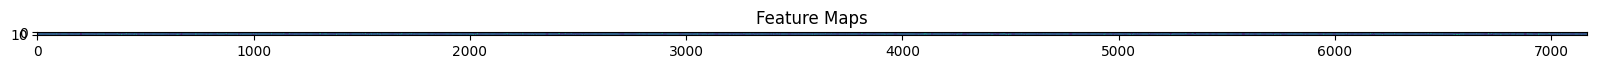

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(scale*no_of_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect="auto")

Feature map shape: (1, 14, 14, 512)


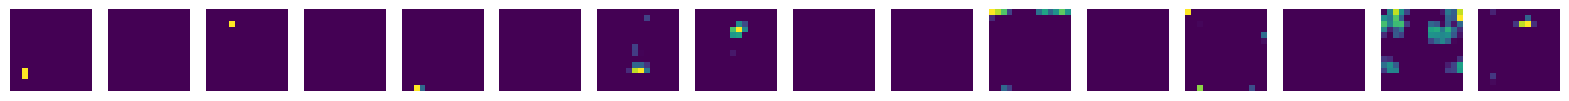

In [126]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

# Visualize the feature maps
def plot_feature_maps(feature_map, num_channels=16):
    """Plot the first num_channels feature maps."""
    channels = feature_map.shape[-1]  # Total channels
    num_channels = min(num_channels, channels)
    fig, axes = plt.subplots(1, num_channels, figsize=(20, 20))
    for i in range(num_channels):
        ax = axes[i]
        ax.imshow(feature_map[0, :, :, i], cmap='viridis')
        ax.axis('off')
    plt.show()

# Display feature maps
print("Feature map shape:", feature_map.shape)  # Shape: (1, height, width, channels)
plot_feature_maps(feature_map, num_channels=16)

ANN

In [127]:

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=50)


In [128]:
radio_cap=pd.read_table("/content/drive/MyDrive/ROCO/data/train/radiology/captions.txt",names=['image_id','caption'])
radio_cap



,image_id,caption
0,ROCO_00002,Computed tomography scan in axial view showin...
1,ROCO_00003,Bacterial contamination occurred after comple...
2,ROCO_00004,The patient had residual paralysis of the han...
3,ROCO_00005,Panoramic radiograph after immediate loading.
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at t...
...,...,...
65445,ROCO_81819,Initial CT abdomen with contrast showing a di...
65446,ROCO_81820,44-year-old male patient after surgical amput...
65447,ROCO_81821,Primary pulmonary tuberculosis in 18-year-old...
65448,ROCO_81822,"MRI brain with gadolinium, coronal view, show..."


In [129]:

for i in range(len(radio_cap['caption'])):
  radio_cap['caption_len']=len(radio_cap['caption'][i])

In [130]:
radio_cap

,image_id,caption,caption_len
0,ROCO_00002,Computed tomography scan in axial view showin...,738
1,ROCO_00003,Bacterial contamination occurred after comple...,738
2,ROCO_00004,The patient had residual paralysis of the han...,738
3,ROCO_00005,Panoramic radiograph after immediate loading.,738
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at t...,738
...,...,...,...
65445,ROCO_81819,Initial CT abdomen with contrast showing a di...,738
65446,ROCO_81820,44-year-old male patient after surgical amput...,738
65447,ROCO_81821,Primary pulmonary tuberculosis in 18-year-old...,738
65448,ROCO_81822,"MRI brain with gadolinium, coronal view, show...",738


In [131]:
X=tfidf.fit_transform(radio_cap['caption']).toarray()
y=radio_cap['caption_len']

In [132]:
X

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.68329382, 0.        , ..., 0.        , 0.43409196,
        0.        ],
       [0.        , 0.1832867 , 0.        , ..., 0.        , 0.11644081,
        0.20019426],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.21751508,
        0.37396914],
       [0.        , 0.        , 0.        , ..., 0.        , 0.43270645,
        0.        ],
       [0.16635985, 0.14094411, 0.        , ..., 0.        , 0.17908169,
        0.30789141]])

In [133]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy


In [134]:

model=Sequential([
                Dense(64,activation="relu",input_shape=(X.shape[1],)),
                Dropout(0.5),
                Dense(32,activation="relu"),
                Dense(1,activation="sigmoid")

])

In [135]:

model.compile(optimizer=Adam(learning_rate=0.001),loss=BinaryCrossentropy(),metrics=['accuracy'])


In [136]:
model.fit(X,y,epochs=10)


Epoch 1/10
2046/2046 [==============================] - 4s 1ms/step - loss: -27758162.0000 - accuracy: 0.0000e+00
Epoch 2/10
2046/2046 [==============================] - 3s 1ms/step - loss: -315120960.0000 - accuracy: 0.0000e+00
Epoch 3/10
2046/2046 [==============================] - 3s 2ms/step - loss: -1074796800.0000 - accuracy: 0.0000e+00
Epoch 4/10
2046/2046 [==============================] - 3s 1ms/step - loss: -2414942720.0000 - accuracy: 0.0000e+00
Epoch 5/10
2046/2046 [==============================] - 3s 1ms/step - loss: -4447110144.0000 - accuracy: 0.0000e+00
Epoch 6/10
2046/2046 [==============================] - 3s 1ms/step - loss: -7275642368.0000 - accuracy: 0.0000e+00
Epoch 7/10
2046/2046 [==============================] - 3s 1ms/step - loss: -11003235328.0000 - accuracy: 0.0000e+00
Epoch 8/10
2046/2046 [==============================] - 3s 2ms/step - loss: -15767495680.0000 - accuracy: 0.0000e+00
Epoch 9/10
2046/2046 [==============================] - 3s 1ms/step - los

In [137]:
loss,accuracy=model.evaluate(X,y)


2046/2046 [==============================] - 2s 1ms/step - loss: -32751208448.0000 - accuracy: 0.0000e+00


In [138]:
loss,accuracy


(-32751208448.0, 0.0)

In [139]:
model.predict(X)



2046/2046 [==============================] - 2s 952us/step


array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], dtype=float32)

In [140]:
y



,caption_len
0,738
1,738
2,738
3,738
4,738
...,...
65445,738
65446,738
65447,738
65448,738


RNN

In [141]:
!pip install faker

from faker import Faker

fake=Faker()
Faker.seed(42)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.3 MB/s eta 0:00:00


In [142]:
def generate_text_labels(num_samples=10000):
  text=[fake.sentence(nb_words=10) for i in range(num_samples)]
  labels=np.random.randint(0,2,num_samples)
  return text,labels

In [143]:
text,labels=generate_text_labels()


In [144]:
text


['Agent every development say quality throughout beautiful.',
 'All behavior discussion own night respond red information last everything thank.',
 'Recently future choice whatever from behavior benefit suggest.',
 'Enough analysis least by two bad fall pick those gun court attorney product.',
 'World talk term herself law street class great prove.',
 'Participant commercial rock clear here writer.',
 'Detail food shoulder argue start source husband at tree note responsibility defense material.',
 'Central cause seat much section investment on gun young catch management.',
 'Technology check civil quite others his.',
 'You more wife team activity result race Mr environment political born itself law.',
 'Will seven medical blood personal success medical current hear.',
 'Much single morning a food affect upon these.',
 'Dream drive note bad rule staff within mouth call.',
 'Water close month parent who up sense ready require human public health.',
 'Later easy ask again network open acc

In [145]:
labels


array([1, 1, 0, ..., 0, 1, 1])

In [146]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer=Tokenizer(num_words=10000)


tokenizer.fit_on_texts(text)

sequences=tokenizer.texts_to_sequences(text)



In [147]:
sequences


[[537, 201, 903, 868, 427, 46, 494],
 [102, 47, 168, 379, 16, 930, 331, 610, 783, 29, 931],
 [169, 266, 22, 644, 78, 47, 713, 142],
 [645, 299, 170, 202, 646, 143, 428, 267, 17, 79, 714, 715, 611],
 [380, 495, 90, 300, 268, 240, 458, 144, 647],
 [269, 884, 332, 333, 301, 885],
 [869, 804, 381, 121, 496, 103, 171, 302, 459, 203, 784, 460, 429],
 [538, 539, 648, 270, 91, 497, 752, 79, 716, 172, 430],
 [785, 948, 612, 334, 613, 335],
 [13, 173, 23, 852, 805, 431, 870, 806, 122, 62, 830, 54, 268],
 [540, 303, 48, 304, 336, 853, 48, 919, 871],
 [270, 145, 967, 904, 804, 717, 807, 337],
 [432, 461, 203, 143, 614, 174, 204, 872, 338],
 [55, 541, 649, 14, 40, 56, 63, 205, 831, 498, 123, 499],
 [305, 271, 680, 175, 582, 942, 306, 681, 382, 1, 102, 383],
 [615, 753, 307, 650, 953, 146, 147, 905, 206, 3, 651, 384],
 [207, 176, 308, 873, 272, 433, 332, 462, 148, 714, 754],
 [124, 29, 241, 616, 177, 785, 64],
 [652, 80, 960, 47, 339, 340],
 [208, 886, 171, 542, 617, 380, 309, 905, 434, 653, 644],
 

In [148]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences=pad_sequences(sequences,maxlen=20)

In [149]:
padded_sequences[:20]


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        537, 201, 903, 868, 427,  46, 494],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 102,  47, 168, 379,
         16, 930, 331, 610, 783,  29, 931],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 169,
        266,  22, 644,  78,  47, 713, 142],
       [  0,   0,   0,   0,   0,   0,   0, 645, 299, 170, 202, 646, 143,
        428, 267,  17,  79, 714, 715, 611],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 380, 495,
         90, 300, 268, 240, 458, 144, 647],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 269, 884, 332, 333, 301, 885],
       [  0,   0,   0,   0,   0,   0,   0, 869, 804, 381, 121, 496, 103,
        171, 302, 459, 203, 784, 460, 429],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 538, 539, 648, 270,
         91, 497, 752,  79, 716, 172, 430],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  

In [150]:
train_size=int(0.8*len(padded_sequences))
train_size



8000

In [151]:

X_train,X_test=padded_sequences[:train_size],padded_sequences[train_size:]
y_train,y_test=labels[:train_size],labels[train_size:]

In [152]:
X_train


array([[  0,   0,   0, ..., 427,  46, 494],
       [  0,   0,   0, ..., 783,  29, 931],
       [  0,   0,   0, ...,  47, 713, 142],
       ...,
       [  0,   0,   0, ..., 460, 452, 559],
       [  0,   0,   0, ..., 717, 563, 866],
       [  0,   0,   0, ..., 819, 191, 266]], dtype=int32)

In [153]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense


model=Sequential([Embedding(input_dim=5000,output_dim=64,input_length=20),
                  SimpleRNN(64,return_sequences=False),
                  Dense(1,activation="sigmoid")
])

In [154]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)


Epoch 1/10
200/200 [==============================] - 3s 8ms/step - loss: 0.6958 - accuracy: 0.4961 - val_loss: 0.6954 - val_accuracy: 0.4988
Epoch 2/10
200/200 [==============================] - 1s 7ms/step - loss: 0.6038 - accuracy: 0.6862 - val_loss: 0.7558 - val_accuracy: 0.4950
Epoch 3/10
200/200 [==============================] - 1s 7ms/step - loss: 0.4132 - accuracy: 0.8130 - val_loss: 0.8924 - val_accuracy: 0.5069
Epoch 4/10
200/200 [==============================] - 1s 7ms/step - loss: 0.2524 - accuracy: 0.8973 - val_loss: 1.2582 - val_accuracy: 0.5050
Epoch 5/10
200/200 [==============================] - 1s 7ms/step - loss: 0.1463 - accuracy: 0.9467 - val_loss: 1.7298 - val_accuracy: 0.5013
Epoch 6/10
200/200 [==============================] - 1s 7ms/step - loss: 0.0766 - accuracy: 0.9766 - val_loss: 2.1849 - val_accuracy: 0.5150
Epoch 7/10
200/200 [==============================] - 1s 7ms/step - loss: 0.0576 - accuracy: 0.9806 - val_loss: 2.3442 - val_accuracy: 0.4969
Epoch 

In [155]:
model.predict(X_test)


63/63 [==============================] - 0s 2ms/step


array([[7.91947648e-04],
       [1.87818496e-03],
       [1.01070575e-01],
       ...,
       [9.14629025e-04],
       [5.65276860e-05],
       [5.36289951e-03]], dtype=float32)

In [156]:
import pandas as pd
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [177]:
image_folder = '/content/drive/MyDrive/ROCO/data/train/non-radiology/images'

images = []
labels = []

image_files = os.listdir(image_folder)

for filename in image_files:

    img_path = os.path.join(image_folder, filename)
    img = load_img(img_path, target_size=(150, 150))


    img_array = img_to_array(img) / 255.0


    images.append(img_array)

    label = filename.split('_')[0]
    labels.append(label)

# Convert the lists to NumPy arrays
images = np.array(images)
labels = np.array(labels)

# Create a LabelEncoder object
label_encoder = LabelEncoder()

# Fit the encoder to your labels
label_encoder.fit(labels)

# Transform your labels into numerical representations
labels = label_encoder.transform(labels)

# Now you can use these encoded labels for training your model
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [178]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)


Epoch 1/10


ValueError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1384, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1373, in run_step  **
        outputs = model.train_step(data)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1150, in train_step
        y_pred = self(x, training=True)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/input_spec.py", line 298, in assert_input_compatibility
        raise ValueError(

    ValueError: In

In [162]:
import pandas as pd
import numpy as np
import os
import logging
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, TensorBoard

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s: %(message)s',
    handlers=[
        logging.FileHandler('model_training.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# Data Loading with comprehensive error handling
def load_caption_data(file_path):
    try:
        if not os.path.exists(file_path):
            logger.error(f"File not found: {file_path}")
            return None

        data = pd.read_csv(file_path, sep='\t', header=None, names=['Image_ID', 'description'])

        # Additional data validation
        if data.empty:
            logger.warning("Loaded dataframe is empty")
            return None

        logger.info(f"Successfully loaded {len(data)} records")
        return data

    except pd.errors.EmptyDataError:
        logger.error("The file is empty")
        return None
    except pd.errors.ParserError:
        logger.error("Error parsing the file. Check file format.")
        return None
    except Exception as e:
        logger.error(f"Unexpected error loading data: {e}")
        return None

# Preprocessing function with enhanced error handling
def preprocess_text_data(dataframe, max_words=5000):
    try:
        # Tokenization with limited vocabulary
        tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
        tokenizer.fit_on_texts(dataframe['description'])

        # Convert texts to sequences
        text_sequences = tokenizer.texts_to_sequences(dataframe['description'])

        # Dynamically determine padding length with more robust calculation
        sequence_lengths = [len(seq) for seq in text_sequences]
        max_sequence_length = min(
            int(np.percentile(sequence_lengths, 95)),
            200  # Cap at a maximum length to prevent memory issues
        )

        # Pad sequences with error handling
        padded_sequences = pad_sequences(
            text_sequences,
            maxlen=max_sequence_length,
            padding='post',
            truncating='post'
        )

        logger.info(f"Preprocessing complete. Vocab size: {len(tokenizer.word_index)}")
        logger.info(f"Max sequence length: {max_sequence_length}")

        return padded_sequences, tokenizer, max_sequence_length

    except Exception as e:
        logger.error(f"Error in text preprocessing: {e}")
        return None, None, None

# Model construction with improved error handling and GPU compatibility
def create_rnn_model(vocab_size, max_sequence_length):
    try:
        # Check for GPU availability
        physical_devices = tf.config.list_physical_devices('GPU')
        if physical_devices:
            try:
                tf.config.experimental.set_memory_growth(physical_devices[0], True)
                logger.info("GPU memory growth enabled")
            except RuntimeError as e:
                logger.warning(f"Could not set GPU memory growth: {e}")

        model = tf.keras.Sequential([
            tf.keras.layers.Embedding(
                input_dim=vocab_size,
                output_dim=64,
                input_length=max_sequence_length,
                mask_zero=True
            ),
            tf.keras.layers.SimpleRNN(50, activation='relu', return_sequences=False),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])

        # Use mixed precision training for better performance
        tf.keras.mixed_precision.set_global_policy('mixed_float16')

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        return model

    except Exception as e:
        logger.error(f"Error creating model: {e}")
        return None

# Main execution with comprehensive error handling
def main():
    try:
        # Create output directories
        os.makedirs('model_checkpoints', exist_ok=True)
        os.makedirs('logs', exist_ok=True)

        # Load data
        path = "/content/drive/MyDrive/ROCO/data/train/non-radiology/captions.txt"
        text_data = load_caption_data(path)

        if text_data is None:
            logger.error("Failed to load data. Exiting.")
            return

        # Preprocess text
        X, tokenizer, max_seq_length = preprocess_text_data(text_data)

        if X is None or tokenizer is None:
            logger.error("Preprocessing failed. Exiting.")
            return

        # Create labels
        y = text_data['Image_ID'].apply(lambda x: hash(x) % 2)

        # Split data with stratification
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Create and train model
        vocab_size = len(tokenizer.word_index) + 1
        model = create_rnn_model(vocab_size, max_seq_length)

        if model is None:
            logger.error("Model creation failed. Exiting.")
            return

        # Comprehensive callbacks
        model_checkpoint = ModelCheckpoint(
            'model_checkpoints/best_model.h5',
            save_best_only=True,
            monitor='val_loss',
            mode='min'
        )

        csv_logger = CSVLogger('training_log.csv', separator=',', append=True)

        tensorboard_callback = TensorBoard(
            log_dir='./logs',
            histogram_freq=1,
            profile_batch='500,520'
        )

        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        )

        # Fit model with comprehensive logging
        try:
            history = model.fit(
                X_train, y_train,
                epochs=20,  # Increased epochs with early stopping
                batch_size=64,
                validation_split=0.2,
                callbacks=[
                    model_checkpoint,
                    csv_logger,
                    tensorboard_callback,
                    early_stopping
                ],
                verbose=1
            )

            # Evaluate model
            test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
            logger.info(f'Test Loss: {test_loss:.4f}')
            logger.info(f'Test Accuracy: {test_accuracy:.4f}')

            # Save final model
            model.save('final_model.h5')
            logger.info("Model saved successfully")

        except tf.errors.ResourceExhaustedError:
            logger.error("Out of memory. Try reducing batch size or model complexity.")
        except Exception as training_error:
            logger.error(f"Training interrupted: {training_error}")

    except Exception as global_error:
        logger.error(f"Unexpected global error: {global_error}")

if __name__ == '__main__':
    main()

The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


Epoch 1/20
49/49 [==============================] - ETA: 0s - loss: 0.6933 - accuracy: 0.5077

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


49/49 [==============================] - 4s 55ms/step - loss: 0.6933 - accuracy: 0.5077 - val_loss: 0.6931 - val_accuracy: 0.4987
Epoch 2/20
49/49 [==============================] - 2s 47ms/step - loss: 0.6756 - accuracy: 0.6264 - val_loss: 0.6965 - val_accuracy: 0.5013
Epoch 3/20
49/49 [==============================] - 2s 47ms/step - loss: 0.5770 - accuracy: 0.7487 - val_loss: 0.7338 - val_accuracy: 0.5242
Epoch 4/20
49/49 [==============================] - 2s 47ms/step - loss: 0.3028 - accuracy: 0.8812 - val_loss: 1.0032 - val_accuracy: 0.5179
Epoch 5/20
49/49 [==============================] - 2s 45ms/step - loss: 0.1129 - accuracy: 0.9639 - val_loss: 1.3000 - val_accuracy: 0.5242
Epoch 6/20
49/49 [==============================] - 2s 47ms/step - loss: 0.0575 - accuracy: 0.9824 - val_loss: 1.5048 - val_accuracy: 0.5140
Epoch 6: early stopping


LSTM

In [4]:
import os
import logging
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    TensorBoard
)

# Configure comprehensive logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s: %(message)s',
    handlers=[
        logging.FileHandler('lstm_model_training.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

def configure_gpu_memory():
    """Configure GPU memory management."""
    try:
        physical_devices = tf.config.list_physical_devices('GPU')
        if physical_devices:
            tf.config.experimental.set_memory_growth(physical_devices[0], True)
            logger.info("GPU memory growth enabled")
        return physical_devices
    except Exception as e:
        logger.warning(f"GPU configuration error: {e}")
        return []

def load_and_validate_data(file_path, min_samples=100):
    """
    Load and validate text data with comprehensive checks.

    Args:
        file_path (str): Path to the text data file
        min_samples (int): Minimum number of samples required

    Returns:
        pd.DataFrame or None
    """
    try:
        # Validate file existence
        if not os.path.exists(file_path):
            logger.error(f"File not found: {file_path}")
            return None

        # Read data
        data = pd.read_csv(file_path, sep='\t', header=None, names=['Image_ID', 'description'])

        # Validate data
        if data.empty:
            logger.error("Loaded dataset is empty")
            return None

        # Check minimum samples
        if len(data) < min_samples:
            logger.warning(f"Insufficient samples: {len(data)} < {min_samples}")
            return None

        # Remove duplicates and null values
        data.dropna(subset=['description'], inplace=True)
        data.drop_duplicates(subset=['description'], inplace=True)

        logger.info(f"Loaded {len(data)} valid text samples")
        return data

    except Exception as e:
        logger.error(f"Data loading error: {e}")
        return None

def preprocess_text_data(
    dataframe,
    max_words=5000,
    max_sequence_length=200
):
    """
    Preprocess text data for LSTM model.

    Args:
        dataframe (pd.DataFrame): Input dataframe
        max_words (int): Maximum vocabulary size
        max_sequence_length (int): Maximum sequence length

    Returns:
        Tuple of preprocessed sequences, tokenizer, and max sequence length
    """
    try:
        # Tokenization
        tokenizer = Tokenizer(
            num_words=max_words,
            oov_token='<OOV>',
            lower=True
        )
        tokenizer.fit_on_texts(dataframe['description'])

        # Convert to sequences
        text_sequences = tokenizer.texts_to_sequences(dataframe['description'])

        # Pad sequences
        padded_sequences = pad_sequences(
            text_sequences,
            maxlen=max_sequence_length,
            padding='post',
            truncating='post'
        )

        logger.info(f"Vocabulary size: {len(tokenizer.word_index)}")
        logger.info(f"Padded sequence shape: {padded_sequences.shape}")

        return padded_sequences, tokenizer, max_sequence_length

    except Exception as e:
        logger.error(f"Text preprocessing error: {e}")
        return None, None, None

def create_lstm_model(
    vocab_size,
    max_sequence_length,
    embedding_dim=100,
    lstm_units=64
):
    """
    Create an LSTM model with multiple layers.

    Args:
        vocab_size (int): Size of vocabulary
        max_sequence_length (int): Maximum sequence length
        embedding_dim (int): Embedding layer dimension
        lstm_units (int): Number of LSTM units

    Returns:
        Compiled Keras model
    """
    try:
        model = tf.keras.Sequential([
            # Embedding layer
            tf.keras.layers.Embedding(
                input_dim=vocab_size,
                output_dim=embedding_dim,
                input_length=max_sequence_length,
                mask_zero=True
            ),

            # Bidirectional LSTM for better context capture
            tf.keras.layers.Bidirectional(
                tf.keras.layers.LSTM(
                    lstm_units,
                    return_sequences=True,
                    dropout=0.3,
                    recurrent_dropout=0.3
                )
            ),

            # Global Max Pooling for feature extraction
            tf.keras.layers.GlobalMaxPooling1D(),

            # Dense layers with dropout for regularization
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dropout(0.5),

            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dropout(0.3),

            # Output layer
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])

        # Compile model with adaptive learning rate
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=['accuracy', 'AUC']
        )

        return model

    except Exception as e:
        logger.error(f"Model creation error: {e}")
        return None

def train_lstm_model(
    X_train, y_train,
    X_test, y_test,
    vocab_size,
    max_sequence_length
):
    """
    Train LSTM model with comprehensive callbacks and logging.

    Args:
        X_train, y_train: Training data
        X_test, y_test: Testing data
        vocab_size: Vocabulary size
        max_sequence_length: Maximum sequence length

    Returns:
        Trained model or None
    """
    # Create model
    model = create_lstm_model(vocab_size, max_sequence_length)

    if model is None:
        logger.error("Failed to create model")
        return None

    # Create output directories
    os.makedirs('lstm_model_checkpoints', exist_ok=True)
    os.makedirs('lstm_logs', exist_ok=True)

    # Callbacks
    callbacks = [
        # Save best model
        ModelCheckpoint(
            'lstm_model_checkpoints/best_lstm_model.h5',
            save_best_only=True,
            monitor='val_accuracy',
            mode='max'
        ),

        # Early stopping to prevent overfitting
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),

        # Reduce learning rate when plateau occurs
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-5
        ),

        # TensorBoard for advanced monitoring
        TensorBoard(
            log_dir='./lstm_logs',
            histogram_freq=1,
            profile_batch='500,520'
        )
    ]

    # Train model
    try:
        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=64,
            validation_data=(X_test, y_test),
            callbacks=callbacks,
            verbose=1
        )

        # Evaluate model
        test_loss, test_accuracy, test_auc = model.evaluate(X_test, y_test, verbose=0)

        logger.info(f'Test Loss: {test_loss:.4f}')
        logger.info(f'Test Accuracy: {test_accuracy:.4f}')
        logger.info(f'Test AUC: {test_auc:.4f}')

        return model

    except Exception as e:
        logger.error(f"Model training error: {e}")
        return None

def main():
    """
    Main execution function with comprehensive error handling.
    """
    try:
        # GPU configuration
        configure_gpu_memory()

        # File path (adjust as needed)
        path = "/content/drive/MyDrive/ROCO/data/train/non-radiology/captions.txt"

        # Load data
        text_data = load_and_validate_data(path)
        if text_data is None:
            logger.error("Data loading failed")
            return

        # Preprocess text
        X, tokenizer, max_seq_length = preprocess_text_data(text_data)
        if X is None:
            logger.error("Text preprocessing failed")
            return

        # Create labels (example method)
        y = text_data['Image_ID'].apply(lambda x: hash(x) % 2)

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Vocabulary size
        vocab_size = len(tokenizer.word_index) + 1

        # Train model
        model = train_lstm_model(
            X_train, y_train,
            X_test, y_test,
            vocab_size,
            max_seq_length
        )

        if model:
            # Save final model
            model.save('final_lstm_model.h5')
            logger.info("Model training completed successfully")
        else:
            logger.error("Model training failed")

    except Exception as e:
        logger.error(f"Unexpected error in main execution: {e}")

if __name__ == '__main__':
    main()

Epoch 1/50
62/62 [==============================] - ETA: 0s - loss: 0.6933 - accuracy: 0.5056 - auc: 0.4991

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


62/62 [==============================] - 60s 849ms/step - loss: 0.6933 - accuracy: 0.5056 - auc: 0.4991 - val_loss: 0.6932 - val_accuracy: 0.4939 - val_auc: 0.4948 - lr: 0.0010
Epoch 2/50
62/62 [==============================] - 50s 810ms/step - loss: 0.6932 - accuracy: 0.5102 - auc: 0.5059 - val_loss: 0.6932 - val_accuracy: 0.5031 - val_auc: 0.4966 - lr: 0.0010
Epoch 3/50
62/62 [==============================] - 50s 806ms/step - loss: 0.6868 - accuracy: 0.5640 - auc: 0.5857 - val_loss: 0.7456 - val_accuracy: 0.4796 - val_auc: 0.4810 - lr: 0.0010
Epoch 4/50
62/62 [==============================] - 49s 800ms/step - loss: 0.6234 - accuracy: 0.6768 - auc: 0.7216 - val_loss: 0.7744 - val_accuracy: 0.4939 - val_auc: 0.4774 - lr: 0.0010
Epoch 5/50
62/62 [==============================] - 49s 799ms/step - loss: 0.4507 - accuracy: 0.8063 - auc: 0.8797 - val_loss: 0.9537 - val_accuracy: 0.4826 - val_auc: 0.4786 - lr: 5.0000e-04
Epoch 6/50
62/62 [==============================] - 50s 813ms/step 